In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install torchmetrics
!pip install eofs
!pip install basemap basemap-data-hires
!pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 22.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.5/30.5 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 4.8 MB/s eta 0:00:00
  Attempting uninstall: pyshp
    Found existing installation: pyshp 3.0.3
    Uninstalling pyshp-3.0.3:
      Successfully uninstalled pyshp-3.0.3
  Attempting uninstall: packaging
    Found existing installation: packaging 26.0
    Uninstalling packaging-26.0:
      Successfully uninstalled packaging-26.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 80.7 MB/s eta 0:00:00


In [3]:
import os
import xarray as xr
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.signal import detrend
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from eofs.standard import Eof
from scipy import signal

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
import numpy as np
from sklearn.utils import shuffle
import torch
import xarray as xr
from scipy.signal import detrend
import netCDF4 as nc
import numpy as np

# ================================================================
def get_datalists(path, N=25):

    train_X, train_Y = [], []
    test_X, test_Y = [], []
    val_X, val_Y = [], []

    trY_SST_ds = xr.open_dataset(path, engine="netcdf4")
    trY_SST_ds = trY_SST_ds.fillna(0)

    print(trY_SST_ds)

    for i in range(N):
        trY_SST = trY_SST_ds['sst'].values[i:i+1]

        print(f"{i+1}th Data Loaded...")

        # trY_SST_anom=trY_SST-np.expand_dims(trY_SST.mean(1),1)
        trY_SST_detrended = detrend(trY_SST, axis=1) # Detrending trY_SST

        trY_SST = torch.tensor(trY_SST_detrended.reshape(trY_SST.shape[0],1980,48,144))#.reshape(16800,48,144)  # Anomaly Data

        trY_SST_train = trY_SST[:,:1680] #1871-1989
        trY_SST_test = trY_SST[0,1680:] #1990-2010

        X_train = trY_SST_train[:,:-1,:,:].squeeze(0).unsqueeze(1)
        Y_train = trY_SST_train[:,1:,:,:].squeeze(0).unsqueeze(1)
        train_X.append(X_train)
        train_Y.append(Y_train)

        X_test = trY_SST_test[:-1,:,:]
        Y_test = trY_SST_test[1:,:,:]

        X_valid = X_test[199:].unsqueeze(1)
        Y_valid = Y_test[199:].unsqueeze(1)
        val_X.append(X_valid)
        val_Y.append(Y_valid)

        X_test = X_test[:199, :, :].unsqueeze(1)
        Y_test = Y_test[:199, :, :].unsqueeze(1)
        test_X.append(X_test)
        test_Y.append(Y_test)

    return train_X, train_Y, test_X, test_Y, val_X, val_Y

In [6]:
path_1 = "/content/drive/MyDrive/SST_Data/GISS-E2-1-H_historical_1850_2014.nc"
train_X, train_Y, test_X, test_Y, val_X, val_Y = get_datalists(path_1, N=10)

<xarray.Dataset> Size: 3GB
Dimensions:   (ensemble: 25, years: 165, mon: 12, lat: 48, lon: 144)
Coordinates:
  * ensemble  (ensemble) <U41 4kB 'tos_Omon_GISS-E2-1-H_historical_r10i1p1f1'...
  * years     (years) int32 660B 1850 1851 1852 1853 ... 2011 2012 2013 2014
  * mon       (mon) int32 48B 0 1 2 3 4 5 6 7 8 9 10 11
  * lat       (lat) float64 384B -88.12 -84.38 -80.62 ... 80.62 84.38 88.12
  * lon       (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
Data variables:
    sst       (ensemble, years, mon, lat, lon) float64 3GB 0.0 0.0 ... -1.732
1th Data Loaded...
2th Data Loaded...
3th Data Loaded...
4th Data Loaded...
5th Data Loaded...
6th Data Loaded...
7th Data Loaded...
8th Data Loaded...
9th Data Loaded...
10th Data Loaded...


In [7]:
len(train_X), len(test_X), len(val_X)
train_X[0].shape, test_X[0].shape, val_X[0].shape

(torch.Size([1679, 1, 48, 144]),
 torch.Size([199, 1, 48, 144]),
 torch.Size([100, 1, 48, 144]))

In [8]:
path_1 = "/content/drive/MyDrive/SST_Data/GISS-E2-1-H_historical_1850_2014.nc"

train_X, train_Y, test_X, test_Y, val_X, val_Y = get_datalists(path_1, N=10)

print("Counts  — train:", len(train_X),
      "| test:", len(test_X),
      "| val:",  len(val_X))
print("Shapes  — train_X[0]:", train_X[0].shape,
      "| test_X[0]:", test_X[0].shape,
      "| val_X[0]:", val_X[0].shape)

# NetCDF4 handle for mask and coordinates
df = nc.Dataset(path_1)

# FIX 6: sst is 4-D (member, time, lat, lon) → only 4 indices needed
mask    = 1 - df.variables['sst'][0, 0, :, :].mask
lat_sst = df.variables['lat'][:]
lon_sst = df.variables['lon'][:]

<xarray.Dataset> Size: 3GB
Dimensions:   (ensemble: 25, years: 165, mon: 12, lat: 48, lon: 144)
Coordinates:
  * ensemble  (ensemble) <U41 4kB 'tos_Omon_GISS-E2-1-H_historical_r10i1p1f1'...
  * years     (years) int32 660B 1850 1851 1852 1853 ... 2011 2012 2013 2014
  * mon       (mon) int32 48B 0 1 2 3 4 5 6 7 8 9 10 11
  * lat       (lat) float64 384B -88.12 -84.38 -80.62 ... 80.62 84.38 88.12
  * lon       (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
Data variables:
    sst       (ensemble, years, mon, lat, lon) float64 3GB 0.0 0.0 ... -1.732
1th Data Loaded...
2th Data Loaded...
3th Data Loaded...
4th Data Loaded...
5th Data Loaded...
6th Data Loaded...
7th Data Loaded...
8th Data Loaded...
9th Data Loaded...
10th Data Loaded...
Counts  — train: 10 | test: 10 | val: 10
Shapes  — train_X[0]: torch.Size([1679, 1, 48, 144]) | test_X[0]: torch.Size([199, 1, 48, 144]) | val_X[0]: torch.Size([100, 1, 48, 144])


In [9]:
from torch.utils.data import Dataset

class SeqSSTDataset(Dataset):

    def __init__(self, X, Y):
        self.X = X.float()
        self.Y = Y.float()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [10]:
from torch.utils.data import DataLoader

batch_size = 64

train_loaders = []
val_loaders   = []
test_loaders  = []

for i in range(len(train_X)):

    train_dataset = SeqSSTDataset(train_X[i], train_Y[i])
    train_loaders.append(
        DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    )

    val_dataset = SeqSSTDataset(val_X[i], val_Y[i])
    val_loaders.append(
        DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    )

    test_dataset = SeqSSTDataset(test_X[i], test_Y[i])
    test_loaders.append(
        DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    )

In [11]:
print("Total training samples:", len(train_dataset))

Total training samples: 1679


In [12]:
print("Total validation samples:", len(val_dataset))
print("Total test samples:", len(test_dataset))

Total validation samples: 100
Total test samples: 199


In [13]:
if device.type == "cuda":
    print("Using GPU (cuda cores)\n")
else:
    print("Using CPU\n")

Using GPU (cuda cores)



In [14]:
best_val_loss = float("inf")
best_epoch = -1

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Encoder(nn.Module):
    def __init__(self, in_channels=1, latent_dim=128, flattened_size=None, final_conv_channels=None, final_conv_height=None, final_conv_width=None):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 64, 4, 2, 1),   # H/2
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, 4, 2, 1),           # H/4
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 256, 4, 2, 1),          # H/8
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )

        if flattened_size is None:
            raise ValueError("flattened_size must be provided to Encoder")

        self.fc_mu = nn.Linear(flattened_size, latent_dim)
        self.fc_logvar = nn.Linear(flattened_size, latent_dim)

    def forward(self, x):
        x = self.conv(x)
        x = torch.flatten(x, start_dim=1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

In [16]:
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

In [17]:
class Decoder(nn.Module):
    def __init__(self, latent_dim=128, out_channels=1, flattened_size=None, final_conv_channels=None, final_conv_height=None, final_conv_width=None,
                 output_padding_1=(0,0), output_padding_2=(0,0), output_padding_3=(0,0)):
        super().__init__()

        if flattened_size is None or final_conv_channels is None or final_conv_height is None or final_conv_width is None:
            raise ValueError("flattened_size, final_conv_channels, final_conv_height, final_conv_width must be provided to Decoder")

        self.final_conv_channels = final_conv_channels
        self.final_conv_height = final_conv_height
        self.final_conv_width = final_conv_width

        self.fc = nn.Linear(latent_dim, flattened_size)

        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(final_conv_channels, 128, 4, 2, 1, output_padding=output_padding_1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, output_padding=output_padding_2),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, out_channels, 4, 2, 1, output_padding=output_padding_3),
        )

    def forward(self, z):
        z = self.fc(z)
        z = z.view(-1, self.final_conv_channels, self.final_conv_height, self.final_conv_width)
        return self.deconv(z)


In [18]:
class VanillaVAE(nn.Module):
    def __init__(self, in_channels=1, latent_dim=128, input_height=None, input_width=None):
        super().__init__()

        if input_height is None or input_width is None:
            raise ValueError("input_height and input_width must be provided to VanillaVAE")

        # Create a temporary convolutional block to calculate output dimensions
        temp_conv_block = nn.Sequential(
            nn.Conv2d(in_channels, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )

        with torch.no_grad():
            dummy_input = torch.randn(1, in_channels, input_height, input_width)

            # Record intermediate sizes from Encoder path for calculating output_padding
            x_enc_l0 = dummy_input # (1, 1, input_height, input_width)
            x_enc_l1 = temp_conv_block[0:3](x_enc_l0) # Output of first conv+bn+relu
            x_enc_l2 = temp_conv_block[3:6](x_enc_l1) # Output of second conv+bn+relu
            x_enc_l3 = temp_conv_block[6:](x_enc_l2)  # Output of third conv+bn+relu

            final_conv_channels = x_enc_l3.shape[1]
            final_conv_height = x_enc_l3.shape[2]
            final_conv_width = x_enc_l3.shape[3]
            flattened_size = final_conv_channels * final_conv_height * final_conv_width

            # Calculate output_padding for decoder layers to match encoder's intermediate sizes
            # Formula for ConvTranspose2d output size: (input_size - 1)*stride - 2*padding + kernel_size + output_padding
            # So, output_padding = target_output_size - ((input_size - 1)*stride - 2*padding + kernel_size)

            # Deconv Layer 1 (corresponds to Enc Layer 3)
            op1_h = x_enc_l2.shape[2] - ((final_conv_height - 1)*2 - 2*1 + 4)
            op1_w = x_enc_l2.shape[3] - ((final_conv_width - 1)*2 - 2*1 + 4)
            output_padding_1 = (op1_h, op1_w)

            # Deconv Layer 2 (corresponds to Enc Layer 2)
            op2_h = x_enc_l1.shape[2] - ((x_enc_l2.shape[2] - 1)*2 - 2*1 + 4)
            op2_w = x_enc_l1.shape[3] - ((x_enc_l2.shape[3] - 1)*2 - 2*1 + 4)
            output_padding_2 = (op2_h, op2_w)

            # Deconv Layer 3 (corresponds to Enc Layer 1)
            op3_h = input_height - ((x_enc_l1.shape[2] - 1)*2 - 2*1 + 4)
            op3_w = input_width - ((x_enc_l1.shape[3] - 1)*2 - 2*1 + 4)
            output_padding_3 = (op3_h, op3_w)

        self.encoder = Encoder(in_channels, latent_dim, flattened_size, final_conv_channels, final_conv_height, final_conv_width)
        self.decoder = Decoder(latent_dim, in_channels, flattened_size, final_conv_channels, final_conv_height, final_conv_width,
                               output_padding_1=output_padding_1,
                               output_padding_2=output_padding_2,
                               output_padding_3=output_padding_3)

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

In [19]:
def vae_loss(recon, x, mu, logvar, beta=1.0):
    recon_loss = F.mse_loss(recon, x)
    kl_loss    = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    loss       = recon_loss + beta * kl_loss
    return loss, recon_loss, kl_loss

In [20]:
input_height = train_X[0].shape[2]   # 48
input_width  = train_X[0].shape[3]   # 144

print(f"Input spatial size: {input_height} x {input_width}")

model     = VanillaVAE(in_channels=1, latent_dim=128,
                        input_height=input_height,
                        input_width=input_width).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Input spatial size: 48 x 144


In [21]:
import time
import torch
import matplotlib.pyplot as plt

In [22]:
epochs = 80  # Set the number of epochs

train_losses = []
val_losses = []

train_times = []
val_times = []

train_gpu_allocated = []
train_gpu_peak = []

val_gpu_allocated = []
val_gpu_peak = []

best_val_loss = float("inf")
best_model_state = None

best_val_loss = float('inf')
best_model_state = None


In [23]:
# best_model_path = "/content/drive/MyDrive/VAE_Checkpoints/best_vanilla_vae_model_128.pth"

In [24]:
save_dir = "/content/drive/MyDrive/SST_Data/Vanilla_VAE_Checkpoints"
os.makedirs(save_dir, exist_ok=True)

best_model_path = os.path.join(save_dir, "best_vanilla_vae_model_128.pth")
last_model_path = os.path.join(save_dir, "last_model_128.pth")

In [25]:
# ================================================================
# TRAINING LOOP
# Save ONLY:
#   best_model.pth
#   last_model.pth
# ================================================================

epochs = 80

train_losses, val_losses = [], []
train_times, val_times = [], []
train_gpu_allocated, val_gpu_allocated = [], []
train_gpu_peak, val_gpu_peak = [], []

best_val_loss = float("inf")

total_training_start = time.time()

for epoch in range(epochs):

    print(f"\nEpoch {epoch+1}/{epochs}")

    # ----------------------------------------------------------
    # TRAINING PHASE
    # ----------------------------------------------------------
    if device.type == "cuda":
        torch.cuda.synchronize()
        torch.cuda.reset_peak_memory_stats()

    train_start = time.time()
    model.train()

    total_train_loss = 0.0
    train_batches = 0

    for loader in train_loaders:
        for x, _ in loader:

            x = x.float().to(device)

            recon, mu, logvar = model(x)
            loss, _, _ = vae_loss(recon, x, mu, logvar)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()
            train_batches += 1

    if device.type == "cuda":
        torch.cuda.synchronize()
        train_allocated = torch.cuda.memory_allocated() / (1024**2)
        train_peak = torch.cuda.max_memory_allocated() / (1024**2)
    else:
        train_allocated = train_peak = 0.0

    train_time = time.time() - train_start
    avg_train_loss = total_train_loss / train_batches

    train_losses.append(avg_train_loss)
    train_times.append(train_time)
    train_gpu_allocated.append(train_allocated)
    train_gpu_peak.append(train_peak)

    # ----------------------------------------------------------
    # VALIDATION PHASE
    # ----------------------------------------------------------
    if device.type == "cuda":
        torch.cuda.synchronize()
        torch.cuda.reset_peak_memory_stats()

    val_start = time.time()
    model.eval()

    total_val_loss = 0.0
    val_batches = 0

    with torch.no_grad():
        for loader in val_loaders:
            for x_val, _ in loader:

                x_val = x_val.float().to(device)

                recon_val, mu_val, logvar_val = model(x_val)
                loss_val, _, _ = vae_loss(recon_val, x_val, mu_val, logvar_val)

                total_val_loss += loss_val.item()
                val_batches += 1

    if device.type == "cuda":
        torch.cuda.synchronize()
        val_allocated = torch.cuda.memory_allocated() / (1024**2)
        val_peak = torch.cuda.max_memory_allocated() / (1024**2)
    else:
        val_allocated = val_peak = 0.0

    val_time = time.time() - val_start
    avg_val_loss = total_val_loss / val_batches

    val_losses.append(avg_val_loss)
    val_times.append(val_time)
    val_gpu_allocated.append(val_allocated)
    val_gpu_peak.append(val_peak)

    # ----------------------------------------------------------
    # LOGGING
    # ----------------------------------------------------------
    print(f"Train | Loss: {avg_train_loss:.6f} | "
          f"Time: {train_time:.2f}s | "
          f"GPU: {train_allocated:.1f}MB (Peak {train_peak:.1f}MB)")

    print(f"Val   | Loss: {avg_val_loss:.6f} | "
          f"Time: {val_time:.2f}s | "
          f"GPU: {val_allocated:.1f}MB (Peak {val_peak:.1f}MB)")

    # ----------------------------------------------------------
    # SAVE LAST MODEL (every epoch)
    # ----------------------------------------------------------
    last_model = {
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_loss": avg_train_loss,
        "val_loss": avg_val_loss
    }

    torch.save(last_model, last_model_path)

    # ----------------------------------------------------------
    # SAVE BEST MODEL
    # ----------------------------------------------------------
    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss

        torch.save(model.state_dict(), best_model_path)

        print("  --> New best model saved")


total_training_time = time.time() - total_training_start

print(f"\nTotal training time: {total_training_time/60:.2f} minutes")
print("Best model saved to:", best_model_path)
print("Last model saved to:", last_model_path)


Epoch 1/80
Train | Loss: 1.049265 | Time: 17.93s | GPU: 207.3MB (Peak 748.9MB)
Val   | Loss: 0.430898 | Time: 0.30s | GPU: 209.2MB (Peak 640.5MB)
  --> New best model saved

Epoch 2/80
Train | Loss: 0.264633 | Time: 13.54s | GPU: 209.2MB (Peak 750.5MB)
Val   | Loss: 0.341697 | Time: 0.29s | GPU: 209.2MB (Peak 640.5MB)
  --> New best model saved

Epoch 3/80
Train | Loss: 0.222600 | Time: 14.10s | GPU: 209.2MB (Peak 750.5MB)
Val   | Loss: 0.318185 | Time: 0.33s | GPU: 209.2MB (Peak 640.5MB)
  --> New best model saved

Epoch 4/80
Train | Loss: 0.213634 | Time: 14.38s | GPU: 209.2MB (Peak 750.5MB)
Val   | Loss: 0.299960 | Time: 0.31s | GPU: 209.2MB (Peak 640.5MB)
  --> New best model saved

Epoch 5/80
Train | Loss: 0.206704 | Time: 14.70s | GPU: 209.2MB (Peak 750.5MB)
Val   | Loss: 0.291776 | Time: 0.31s | GPU: 209.2MB (Peak 640.5MB)
  --> New best model saved

Epoch 6/80
Train | Loss: 0.236655 | Time: 14.57s | GPU: 209.2MB (Peak 750.5MB)
Val   | Loss: 0.317334 | Time: 0.30s | GPU: 209.2M

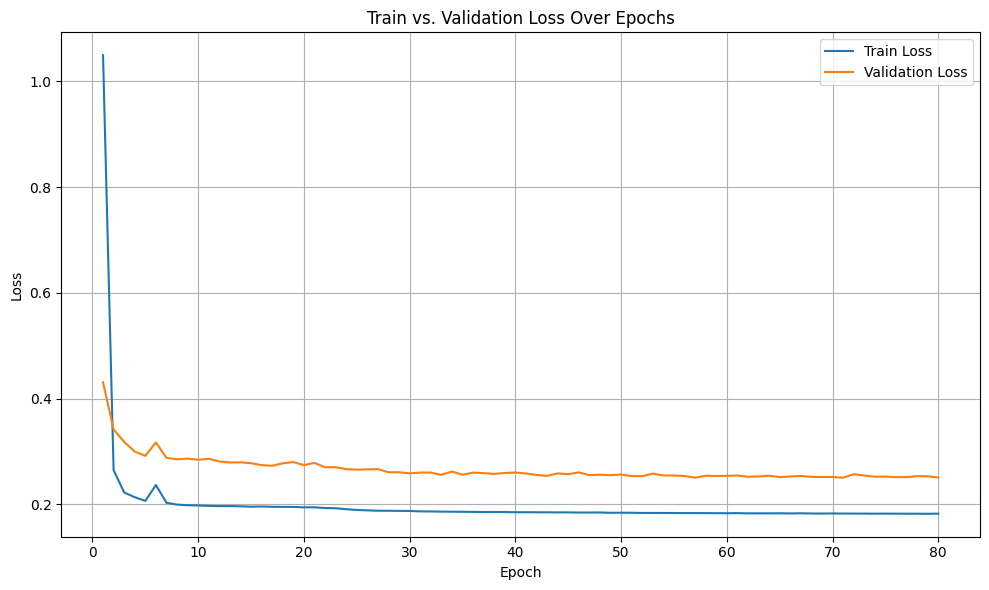

In [26]:
# # Save the best model to a file
# if best_model_state is not None:
#     torch.save(best_model_state, best_model_path)
#     print("Best model saved to:", best_model_path)

# Plotting train vs. validation loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label="Train Loss")
plt.plot(range(1, epochs + 1), val_losses,   label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs. Validation Loss Over Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
# ================================================================
# LOAD BEST MODEL
# ================================================================

model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()
print("Best model loaded from:", best_model_path)


# ================================================================
# ESTIMATE LATENT STATISTICS
# FIX 1: SeqSSTDataset returns (X, Y) — unpack as (x, _), not 4 values
# ================================================================

def estimate_latent_stats(model, train_loaders, device):

    model.eval()
    all_mu = []

    with torch.no_grad():

        for loader in train_loaders:

            for x, _ in loader:                      # FIX 1: correct unpack

                x = x.float().to(device)

                mu, logvar = model.encoder(x)        # encode only

                all_mu.append(mu.cpu())

    all_mu = torch.cat(all_mu, dim=0)                # (N_total, latent_dim)

    latent_std = all_mu.std(dim=0).mean().item()

    print(f"Estimated latent std across training set: {latent_std:.6f}")

    return latent_std

Best model loaded from: /content/drive/MyDrive/SST_Data/Vanilla_VAE_Checkpoints/best_vanilla_vae_model_128.pth


In [28]:
latent_std = estimate_latent_stats(model, train_loaders, device)

Estimated latent std across training set: 0.108945


In [29]:
def generate_test_sequences(
    model,
    test_X,
    device,
    use_prior=False,
    seed=42
):
    """
    Generate SST reconstructions / samples for every test ensemble.

    Parameters
    ----------
    model      : trained VanillaVAE
    test_X     : list of tensors, each (T, 1, H, W)
    device     : torch device
    use_prior  : if True, sample z from N(0,I) for each step (pure generation).
                 if False, encode the ground-truth frame and sample from
                 the posterior q(z|x_t)  (reconstruction / teacher-forced).
    seed       : random seed for reproducibility

    Returns
    -------
    all_ensembles_generated : np.ndarray of shape (N_ens, T, 1, H, W)
    """

    torch.manual_seed(seed)
    np.random.seed(seed)

    model.eval()
    all_ensembles_generated = []

    with torch.no_grad():

        for ens in range(len(test_X)):

            print(f"Generating ensemble {ens + 1}/{len(test_X)}")

            # X_all shape: (T, 1, H, W)
            X_all     = test_X[ens].float().to(device)
            num_steps = X_all.shape[0]

            generated_sequence = []

            for t in range(num_steps):

                x_t = X_all[t : t + 1]               # (1, 1, H, W)

                if use_prior:
                    # ---- Pure prior: z ~ N(0, I) ----
                    # z_t = torch.randn(
                    #     1, model.latent_dim, device=device
                    # )                                 # (1, latent_dim)
                    latent_dim = model.encoder.fc_mu.out_features
                    z_t = torch.randn(1, latent_dim, device=device)

                else:
                    # ---- Posterior: z ~ q(z | x_t) ----
                    mu, logvar = model.encoder(x_t)
                    std        = torch.exp(0.5 * logvar)
                    eps        = torch.randn_like(std)
                    z_t        = mu + std * eps       # (1, latent_dim)

                # Decode
                x_t_pred = model.decoder(z_t)         # (1, 1, H, W)

                generated_sequence.append(x_t_pred.cpu().numpy())

            # Stack time steps → (T, 1, H, W)
            generated_ensemble = np.concatenate(generated_sequence, axis=0)
            all_ensembles_generated.append(generated_ensemble)

    # Stack ensembles → (N_ens, T, 1, H, W)
    all_ensembles_generated = np.stack(all_ensembles_generated, axis=0)

    return all_ensembles_generated

In [30]:
# Generate using posterior (teacher-forced reconstruction)
generated_test = generate_test_sequences(
    model,
    test_X,
    device,
    use_prior=True,   # set True for pure prior sampling
    seed=42
)

print("Generated shape (before squeeze):", generated_test.shape)
# → (N_ens, T, 1, H, W)

# Squeeze channel dim → (N_ens, T, H, W)
generated_test = generated_test.squeeze(2)
print("Generated shape (after squeeze) :", generated_test.shape)

# Ground-truth test targets — FIX 6: single definition, placed after squeeze
ori_test = np.stack(
    [test_Y[i].squeeze(1).numpy() for i in range(len(test_Y))],
    axis=0
)                                                      # (N_ens, T, H, W)
print("Original test shape            :", ori_test.shape)

Generating ensemble 1/10
Generating ensemble 2/10
Generating ensemble 3/10
Generating ensemble 4/10
Generating ensemble 5/10
Generating ensemble 6/10
Generating ensemble 7/10
Generating ensemble 8/10
Generating ensemble 9/10
Generating ensemble 10/10
Generated shape (before squeeze): (10, 199, 1, 48, 144)
Generated shape (after squeeze) : (10, 199, 48, 144)
Original test shape            : (10, 199, 48, 144)


In [31]:
gen1 = generate_test_sequences(model, test_X, device, seed=1)
gen2 = generate_test_sequences(model, test_X, device, seed=2)

Generating ensemble 1/10
Generating ensemble 2/10
Generating ensemble 3/10
Generating ensemble 4/10
Generating ensemble 5/10
Generating ensemble 6/10
Generating ensemble 7/10
Generating ensemble 8/10
Generating ensemble 9/10
Generating ensemble 10/10
Generating ensemble 1/10
Generating ensemble 2/10
Generating ensemble 3/10
Generating ensemble 4/10
Generating ensemble 5/10
Generating ensemble 6/10
Generating ensemble 7/10
Generating ensemble 8/10
Generating ensemble 9/10
Generating ensemble 10/10


In [32]:
np.mean((gen1 - gen2)**2)

np.float32(0.024832137)

In [33]:
@torch.no_grad()
def encode_dataset(model, data, device, batch_size=64):
    """
    Encode a spatial SST dataset into latent space.

    Parameters
    ----------
    data : np.ndarray of shape (T, H, W)
           Raw SST frames (no channel dim).

    Returns
    -------
    mus, logvars : torch.Tensor each of shape (T, latent_dim)
    """
    model.eval()
    mus     = []
    logvars = []

    for i in range(0, data.shape[0], batch_size):
        batch = torch.tensor(
            data[i : i + batch_size],
            dtype=torch.float32
        ).unsqueeze(1).to(device)                    # (B, 1, H, W)

        mu, logvar = model.encoder(batch)
        mus.append(mu.cpu())
        logvars.append(logvar.cpu())

    mus     = torch.cat(mus,     dim=0)
    logvars = torch.cat(logvars, dim=0)
    return mus, logvars

In [34]:
@torch.no_grad()
def encode_time_series(model, data, device, batch_size=64):
    """
    Encode SST anomaly time series into latent space.

    Parameters
    ----------
    data : np.ndarray of shape (T, H, W)

    Returns
    -------
    mus, logvars : torch.Tensor each of shape (T, latent_dim)
    """
    model.eval()
    mus     = []
    logvars = []

    for i in range(0, data.shape[0], batch_size):
        batch = torch.tensor(
            data[i : i + batch_size],
            dtype=torch.float32
        ).unsqueeze(1).to(device)                    # (B, 1, H, W)

        mu, logvar = model.encoder(batch)
        mus.append(mu.cpu())
        logvars.append(logvar.cpu())

    mus     = torch.cat(mus,     dim=0)
    logvars = torch.cat(logvars, dim=0)
    return mus, logvars

In [35]:
test_mus, test_logvars = encode_time_series(
    model, ori_test[0], device, batch_size=64
)
print("Encoded test[0] mu shape:", test_mus.shape)

Encoded test[0] mu shape: torch.Size([199, 128])


In [36]:
# ================================================================
# RECONSTRUCT MAPS
# FIX 3: SeqSSTDataset returns (X, Y) — unpack as (x, _)
# ================================================================

def reconstruct_maps(model, data_loader, device):
    """
    Run encoder → decoder on every batch in data_loader and collect
    originals + reconstructions.

    Returns
    -------
    originals        : torch.Tensor (N, 1, H, W)
    reconstructions  : torch.Tensor (N, 1, H, W)
    """
    model.eval()

    originals       = []
    reconstructions = []

    with torch.no_grad():

        for x, _ in data_loader:                     # FIX 3: correct unpack

            x = x.float().to(device)                 # (B, 1, H, W)

            # Encode
            mu, logvar = model.encoder(x)

            # Use mean (deterministic, no noise) for clean visualisation
            z = mu

            # Decode
            recon = model.decoder(z)

            originals.append(x.cpu())
            reconstructions.append(recon.cpu())

    originals       = torch.cat(originals,       dim=0)
    reconstructions = torch.cat(reconstructions, dim=0)

    return originals, reconstructions


orig, recon = reconstruct_maps(model, train_loaders[0], device)
print("orig shape :", orig.shape)
print("recon shape:", recon.shape)

orig shape : torch.Size([1679, 1, 48, 144])
recon shape: torch.Size([1679, 1, 48, 144])


In [37]:
dummy = torch.randn(1,1,48,144).to(device)

mu, logvar = model.encoder(dummy)

print(mu.shape)

torch.Size([1, 128])


In [38]:
print("latent dim used:", model.encoder.fc_mu.out_features)

latent dim used: 128


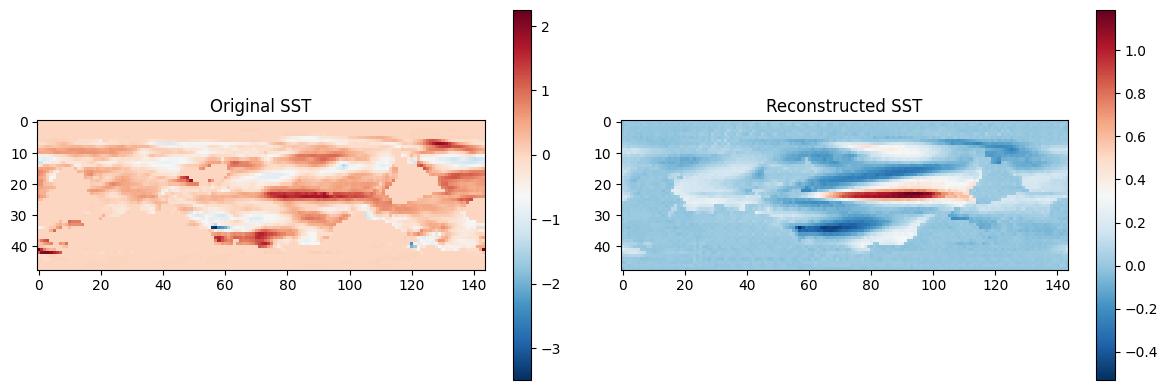

In [39]:
# ================================================================
# VISUALISE RECONSTRUCTION
# ================================================================

idx = 0

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = axes[0].imshow(orig[idx, 0].numpy(),  cmap="RdBu_r")
axes[0].set_title("Original SST")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(recon[idx, 0].numpy(), cmap="RdBu_r")
axes[1].set_title("Reconstructed SST")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

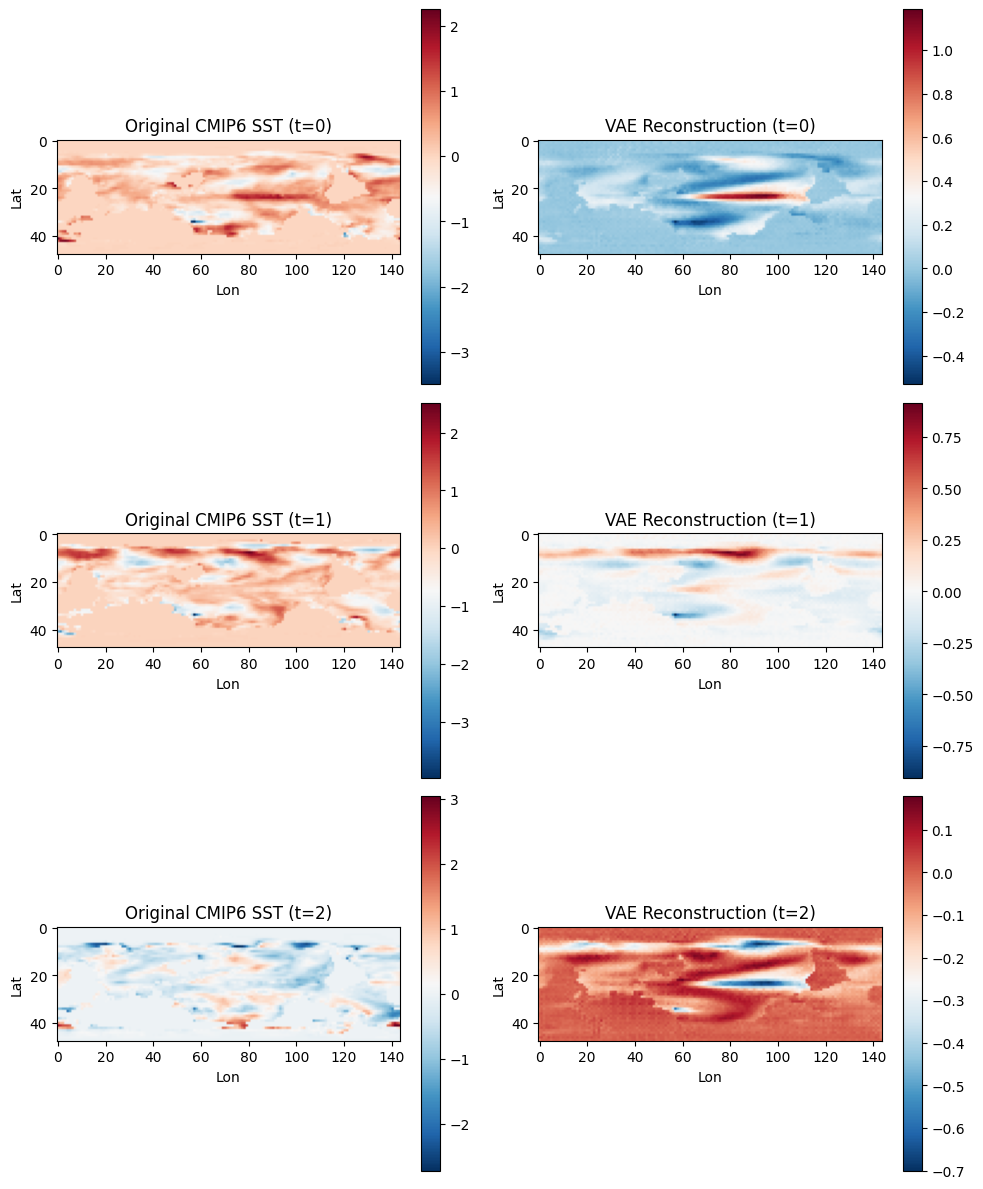

In [40]:
num_examples = 3

fig, axes = plt.subplots(num_examples, 2, figsize=(10, 4*num_examples))

for i in range(num_examples):

    # Original
    im0 = axes[i,0].imshow(orig[i,0].numpy(), cmap="RdBu_r")
    axes[i,0].set_title(f"Original CMIP6 SST (t={i})")
    axes[i,0].set_xlabel("Lon")
    axes[i,0].set_ylabel("Lat")
    plt.colorbar(im0, ax=axes[i,0])

    # Reconstruction
    im1 = axes[i,1].imshow(recon[i,0].numpy(), cmap="RdBu_r")
    axes[i,1].set_title(f"VAE Reconstruction (t={i})")
    axes[i,1].set_xlabel("Lon")
    axes[i,1].set_ylabel("Lat")
    plt.colorbar(im1, ax=axes[i,1])

plt.tight_layout()
plt.show()

In [41]:
lat_vals = np.array(lat_sst)
lon_vals = np.array(lon_sst)

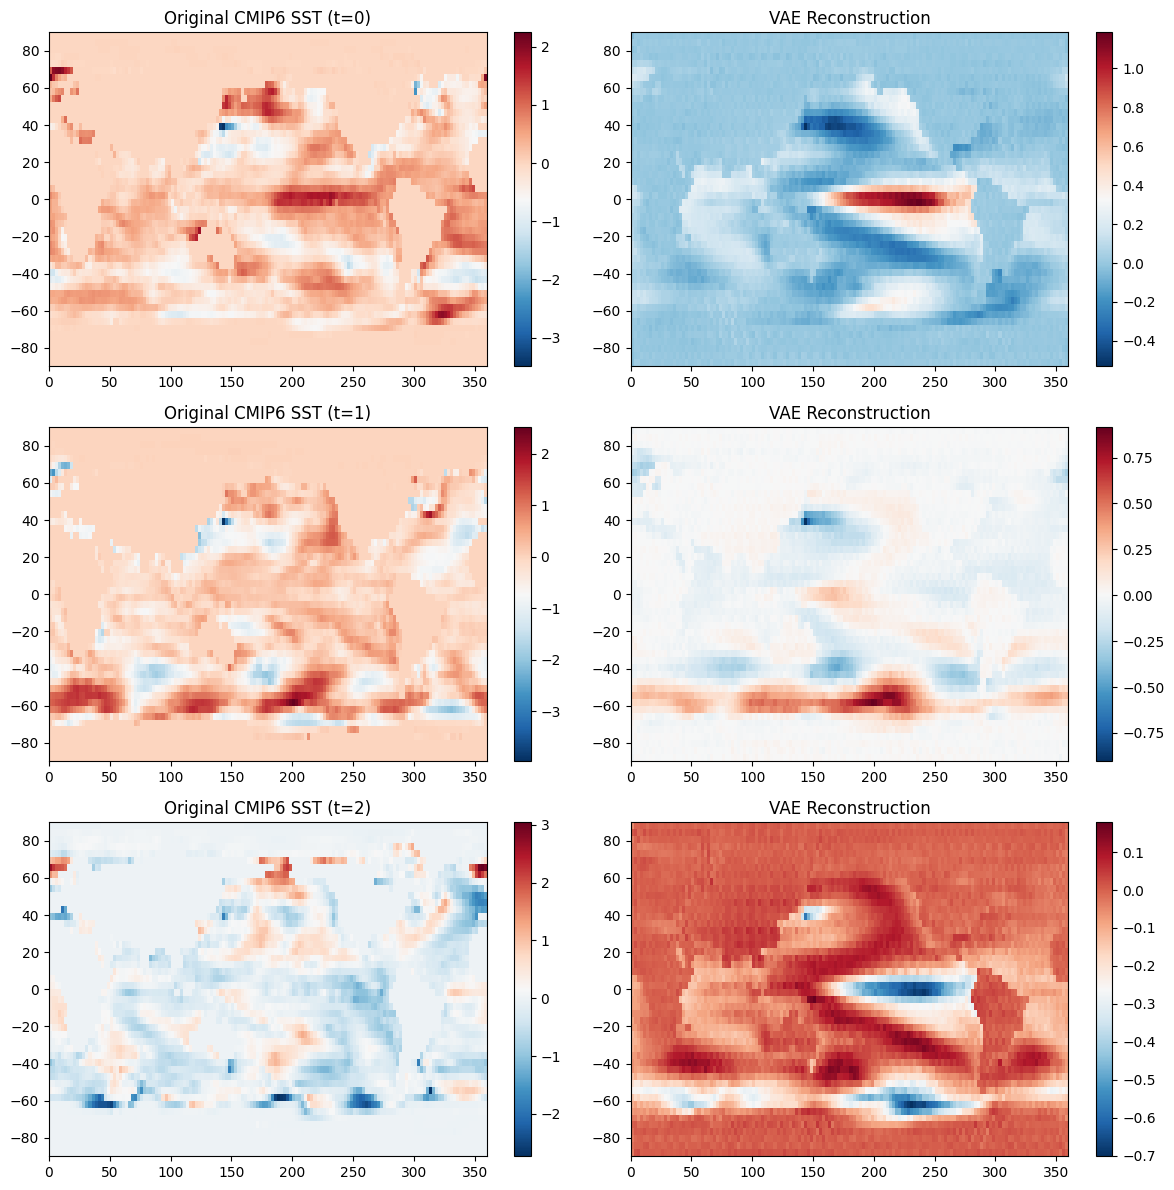

In [42]:
num_examples = 3

fig, axes = plt.subplots(num_examples, 2, figsize=(12, 4*num_examples))

for i in range(num_examples):

    im0 = axes[i,0].pcolormesh(lon_vals, lat_vals, orig[i,0].numpy(),
                               cmap="RdBu_r", shading='auto')
    axes[i,0].set_title(f"Original CMIP6 SST (t={i})")
    plt.colorbar(im0, ax=axes[i,0])

    im1 = axes[i,1].pcolormesh(lon_vals, lat_vals, recon[i,0].numpy(),
                               cmap="RdBu_r", shading='auto')
    axes[i,1].set_title(f"VAE Reconstruction")
    plt.colorbar(im1, ax=axes[i,1])

plt.tight_layout()
plt.show()

In [43]:
# ================================================================
# BUILD XARRAY DATASETS
# FIX 7: convert masked arrays to plain numpy before xarray coords
# FIX 8: time_coord derived after squeeze, shapes consistent
# ================================================================

# FIX 7: strip any MaskedArray wrapper from netCDF4 coordinate reads
lat_vals = np.array(lat_sst)
lon_vals = np.array(lon_sst)

time_coord = np.arange(generated_test.shape[1])   # length T

# Generated VAE output dataset
vae_anom_ds = xr.Dataset(
    {
        "sst": (["ensemble", "time", "lat", "lon"], generated_test)
    },
    coords={
        "ensemble": np.arange(generated_test.shape[0]),
        "time"    : time_coord,
        "lat"     : lat_vals,
        "lon"     : lon_vals,
    }
)

# Original reference dataset
ori_anom_ds = xr.Dataset(
    {
        "sst": (["ensemble", "time", "lat", "lon"], ori_test)
    },
    coords={
        "ensemble": np.arange(ori_test.shape[0]),
        "time"    : time_coord,
        "lat"     : lat_vals,
        "lon"     : lon_vals,
    }
)

print(vae_anom_ds)
print(ori_anom_ds)


<xarray.Dataset> Size: 55MB
Dimensions:   (ensemble: 10, time: 199, lat: 48, lon: 144)
Coordinates:
  * ensemble  (ensemble) int64 80B 0 1 2 3 4 5 6 7 8 9
  * time      (time) int64 2kB 0 1 2 3 4 5 6 7 ... 192 193 194 195 196 197 198
  * lat       (lat) float64 384B -88.12 -84.38 -80.62 ... 80.62 84.38 88.12
  * lon       (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
Data variables:
    sst       (ensemble, time, lat, lon) float32 55MB -0.02868 ... -0.008695
<xarray.Dataset> Size: 110MB
Dimensions:   (ensemble: 10, time: 199, lat: 48, lon: 144)
Coordinates:
  * ensemble  (ensemble) int64 80B 0 1 2 3 4 5 6 7 8 9
  * time      (time) int64 2kB 0 1 2 3 4 5 6 7 ... 192 193 194 195 196 197 198
  * lat       (lat) float64 384B -88.12 -84.38 -80.62 ... 80.62 84.38 88.12
  * lon       (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
Data variables:
    sst       (ensemble, time, lat, lon) float64 110MB 0.0 0.0 ... -0.006414


In [44]:
vae_anom_ds_3mo_avg = (
    vae_anom_ds
    .rolling(time=3, center=True)
    .mean()
    .dropna("time")
)

ori_anom_ds_3mo_avg = (
    ori_anom_ds
    .rolling(time=3, center=True)
    .mean()
    .dropna("time")
)

In [45]:
print("VAE dims:", vae_anom_ds_3mo_avg.sst.dims)
print("VAE shape:", vae_anom_ds_3mo_avg.sst.shape)

print("Original dims:", ori_anom_ds_3mo_avg.sst.dims)
print("Original shape:", ori_anom_ds_3mo_avg.sst.shape)

VAE dims: ('ensemble', 'time', 'lat', 'lon')
VAE shape: (10, 197, 48, 144)
Original dims: ('ensemble', 'time', 'lat', 'lon')
Original shape: (10, 197, 48, 144)


In [61]:
vae_mean_map = vae_anom_ds_3mo_avg.sst.mean(dim=("ensemble", "time")).values
ori_mean_map = ori_anom_ds_3mo_avg.sst.mean(dim=("ensemble", "time")).values

vae_std_map = vae_anom_ds_3mo_avg.sst.std(dim=("ensemble", "time")).values
ori_std_map = ori_anom_ds_3mo_avg.sst.std(dim=("ensemble", "time")).values

In [62]:
lat_vals = vae_anom_ds_3mo_avg.lat.values
lon_vals = vae_anom_ds_3mo_avg.lon.values

In [63]:
def symmetric_range(*arrays):
    """
    Compute symmetric color range around zero
    across multiple arrays.
    """
    max_abs = max(np.nanmax(np.abs(a)) for a in arrays)
    return -max_abs, max_abs

In [64]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.basemap import Basemap

def plot_two_maps_same_range(
    lon, lat,
    data1, data2,
    title1, title2,
    cbar_label="",
    cmap="RdBu_r",
    n_levels=21,
    save_path=None
):
    """
    Plot two global maps side-by-side using the SAME color scale.
    """

    # ----- Shared symmetric range -----
    vmin, vmax = symmetric_range(data1, data2)
    levels = np.linspace(vmin, vmax, n_levels)

    # ----- Figure -----
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    for ax, data, title in zip(
        axes,
        [data1, data2],
        [title1, title2]
    ):
        m = Basemap(
            projection="cyl",
            llcrnrlat=lat.min(),
            urcrnrlat=lat.max(),
            llcrnrlon=lon.min(),
            urcrnrlon=lon.max(),
            resolution="l",
            ax=ax
        )

        lons, lats = np.meshgrid(lon, lat)
        x, y = m(lons, lats)

        cs = m.contourf(
            x, y, data,
            levels=levels,
            cmap=cmap,
            extend="both"
        )

        m.drawcoastlines()
        m.drawparallels(np.arange(-90, 91, 30), labels=[1,0,0,0])
        m.drawmeridians(np.arange(0, 361, 60), labels=[0,0,0,1])
        ax.set_title(title)

    # ----- Shared colorbar -----
    cbar = fig.colorbar(
        cs,
        ax=axes,
        orientation="horizontal",
        pad=0.08,
        aspect=40
    )
    cbar.set_label(cbar_label)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

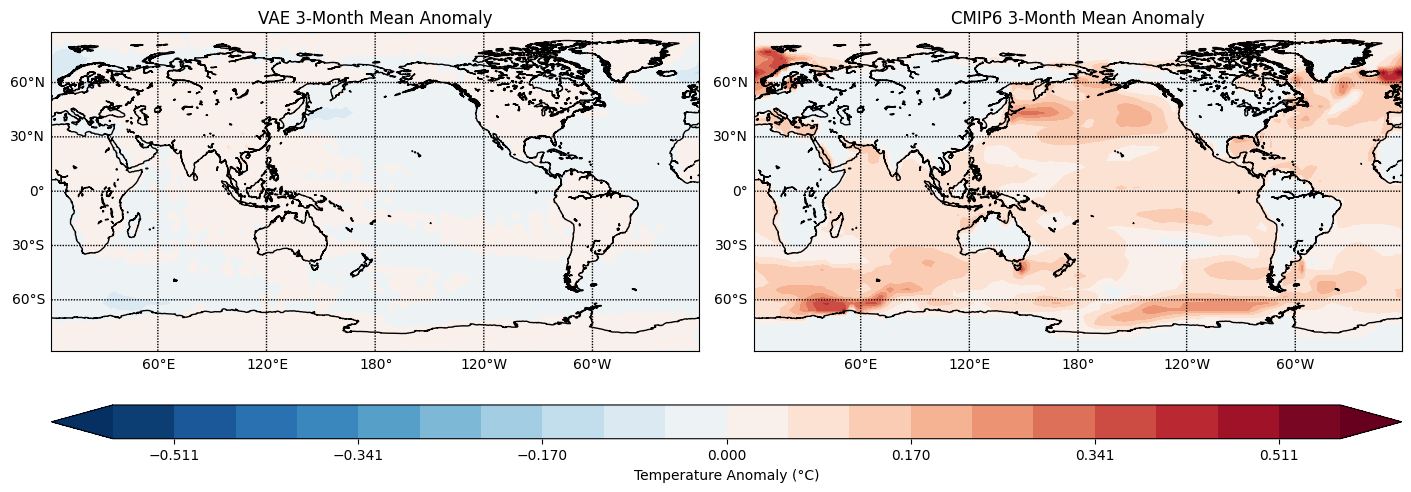

In [66]:
plot_two_maps_same_range(
    lon_vals,
    lat_vals,
    vae_mean_map,
    ori_mean_map,
    title1="VAE 3-Month Mean Anomaly",
    title2="CMIP6 3-Month Mean Anomaly",
    cbar_label="Temperature Anomaly (°C)",
    save_path="/content/drive/MyDrive/VAE_Output/mean_comparison.png"
)

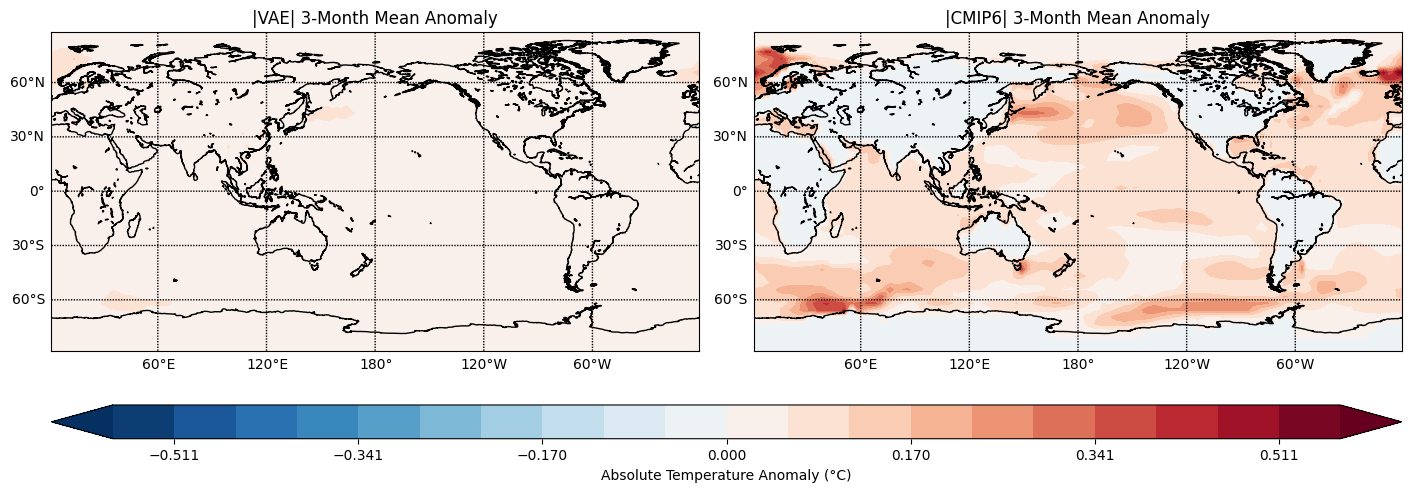

In [67]:
# Compute absolute mean anomaly maps
vae_abs_mean_map = np.abs(vae_mean_map)
ori_abs_mean_map = np.abs(ori_mean_map)

plot_two_maps_same_range(
    lon_vals,
    lat_vals,
    vae_abs_mean_map,
    ori_abs_mean_map,
    title1="|VAE| 3-Month Mean Anomaly",
    title2="|CMIP6| 3-Month Mean Anomaly",
    cbar_label="Absolute Temperature Anomaly (°C)",
    # cmap="viridis",  # better for absolute values
    save_path="/content/drive/MyDrive/VAE_Output/absolute_mean_comparison.png"
)

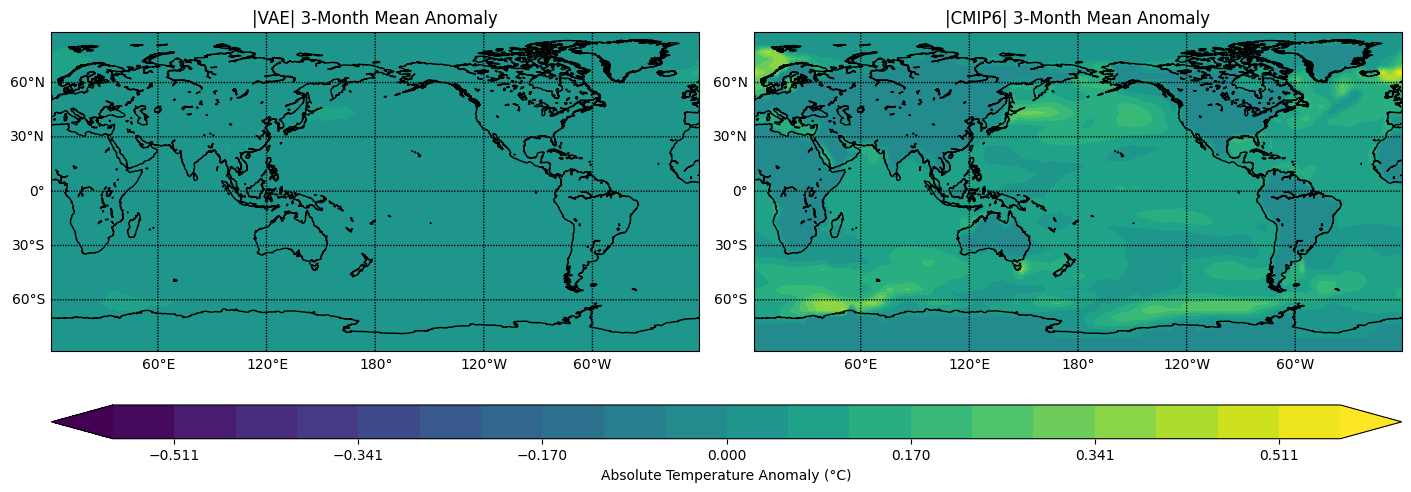

In [68]:
# Compute absolute mean anomaly maps
vae_abs_mean_map = np.abs(vae_mean_map)
ori_abs_mean_map = np.abs(ori_mean_map)

plot_two_maps_same_range(
    lon_vals,
    lat_vals,
    vae_abs_mean_map,
    ori_abs_mean_map,
    title1="|VAE| 3-Month Mean Anomaly",
    title2="|CMIP6| 3-Month Mean Anomaly",
    cbar_label="Absolute Temperature Anomaly (°C)",
    cmap="viridis",  # better for absolute values
    save_path="/content/drive/MyDrive/VAE_Output/absolute_mean_comparison.png"
)

In [69]:
def plot_two_maps_std(
    lon, lat,
    data1, data2,
    title1, title2,
    cbar_label="Std Dev (°C)",
    cmap="OrRd",
    n_levels=21,
    save_path=None
):
    vmax = max(
        np.nanmax(data1),
        np.nanmax(data2)
    )
    # vmax = 1.0
    vmin = 0.0
    # levels = np.linspace(vmin, vmax, n_levels)
    # Fix: Replaced np.nmax with np.nanmax
    levels = np.linspace(vmin, np.nanmax(data1) if np.nanmax(data1) > np.nanmax(data2) else np.nanmax(data2), n_levels) # Use the max of the two datasets, or a single dataset's max if only one is relevant for the levels calculation. Previously, 'data' was undefined in this scope.
    # levels = np.linspace(0, 1.0, n_levels)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    for ax, data, title in zip(axes, [data1, data2], [title1, title2]):
        m = Basemap(
            projection="cyl",
            llcrnrlat=lat.min(),
            urcrnrlat=lat.max(),
            llcrnrlon=lon.min(),
            urcrnrlon=lon.max(),
            resolution="l",
            ax=ax
        )

        lons, lats = np.meshgrid(lon, lat)
        x, y = m(lons, lats)

        cs = m.contourf(
            x, y, data,
            levels=levels,
            cmap=cmap,
            extend="max"
        )

        m.drawcoastlines()
        m.drawparallels(np.arange(-90, 91, 30), labels=[1,0,0,0])
        m.drawmeridians(np.arange(0, 361, 60), labels=[0,0,0,1])
        ax.set_title(title)

    cbar = fig.colorbar(cs, ax=axes, orientation="horizontal", pad=0.08)
    cbar.set_label(cbar_label)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

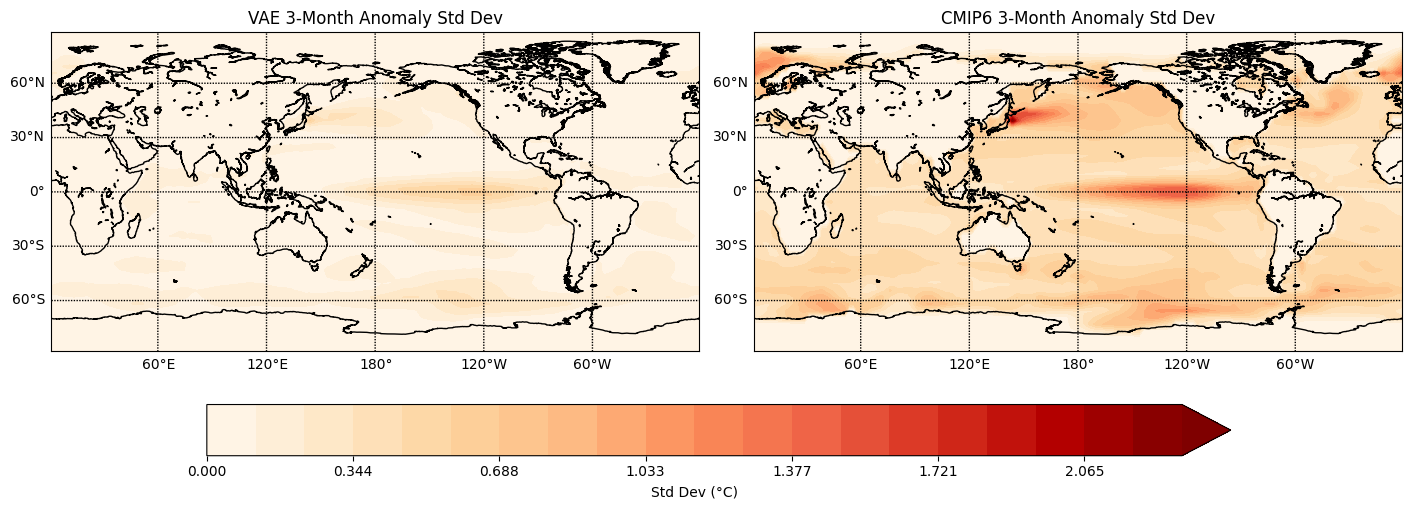

In [70]:
plot_two_maps_std(
    lon_vals,
    lat_vals,
    vae_std_map,
    ori_std_map,
    title1="VAE 3-Month Anomaly Std Dev",
    title2="CMIP6 3-Month Anomaly Std Dev",
    save_path="/content/drive/MyDrive/VAE_Output/std_comparison.png"
)

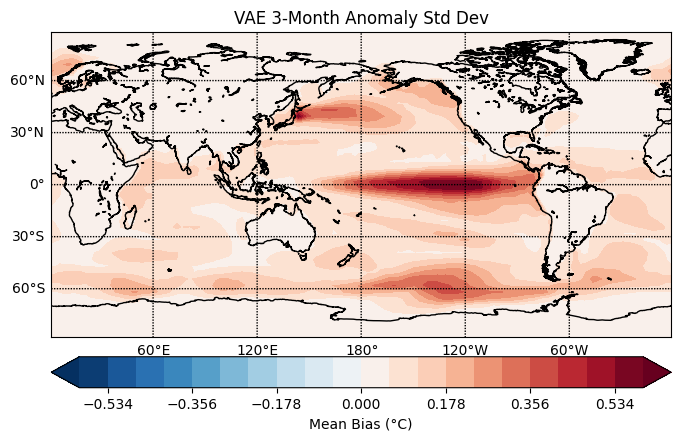

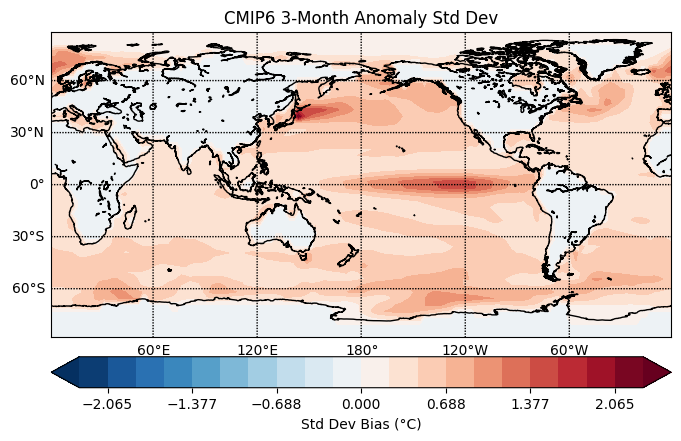

In [71]:
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import numpy as np

def plot_map_metric(lon, lat, data, save_path, title="", cbar_label=""): # New function definition
    plt.figure(figsize=(8,5))
    m = Basemap(
        projection="cyl",
        llcrnrlat=lat.min(),
        urcrnrlat=lat.max(),
        llcrnrlon=lon.min(),
        urcrnrlon=lon.max(),
        resolution="l"
    )

    lons, lats = np.meshgrid(lon, lat)
    x, y = m(lons, lats)

    # Determine levels for contourf, centering around zero for bias
    max_abs = np.nanmax(np.abs(data))
    levels = np.linspace(-max_abs, max_abs, 21) # 21 levels for RdBu_r

    cs = m.contourf(x, y, data, levels=levels, cmap="RdBu_r", extend="both")
    m.drawcoastlines()
    m.drawparallels(np.arange(-90, 91, 30), labels=[1,0,0,0])
    m.drawmeridians(np.arange(0, 361, 60), labels=[0,0,0,1])
    plt.colorbar(cs, orientation="horizontal", pad=0.05, label=cbar_label)
    plt.title(title)
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

plot_map_metric(
    lon_vals, lat_vals,vae_std_map,
    "/content/drive/MyDrive/VAE_Output/bias_map_vae_vs_cmip6.png",
    title="VAE 3-Month Anomaly Std Dev",
    cbar_label="Mean Bias (°C)"
)

plot_map_metric(
    lon_vals, lat_vals, ori_std_map,
    "/content/drive/MyDrive/VAE_Output/std_bias_map_vae_vs_cmip6.png",
    title="CMIP6 3-Month Anomaly Std Dev",
    cbar_label="Std Dev Bias (°C)"
)


In [72]:
import xarray as xr

lat_vals = lat_sst
lon_vals = lon_sst

time_coord = np.arange(generated_test.shape[1])

vae_anom_ds = xr.Dataset(
    {
        "sst": (["ensemble", "time", "lat", "lon"], generated_test)
    },
    coords={
        "ensemble": np.arange(generated_test.shape[0]),
        "time": time_coord,
        "lat": lat_vals,
        "lon": lon_vals,
    }
)

# Original reference dataset
ori_test = np.stack(
    [test_Y[i].squeeze(1).numpy() for i in range(len(test_Y))],
    axis=0
)

ori_anom_ds = xr.Dataset(
    {
        "sst": (["ensemble", "time", "lat", "lon"], ori_test)
    },
    coords={
        "ensemble": np.arange(ori_test.shape[0]),
        "time": time_coord,
        "lat": lat_vals,
        "lon": lon_vals,
    }
)

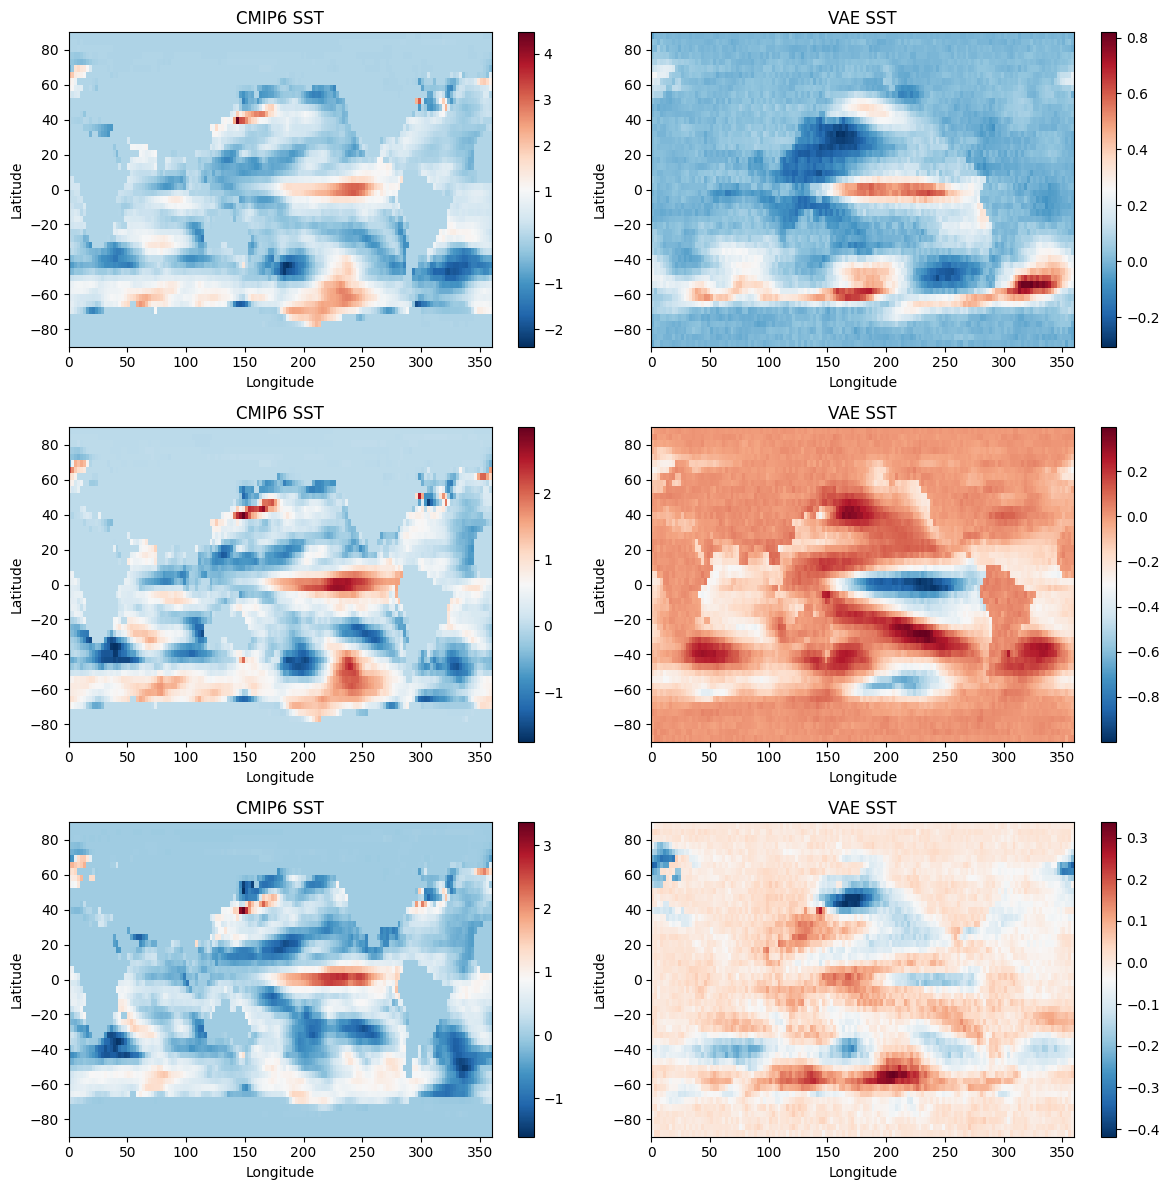

In [73]:
num_samples = 3
ensemble_id = 0   # choose ensemble to visualize

fig, axes = plt.subplots(num_samples, 2, figsize=(12, 4*num_samples))

for i in range(num_samples):

    # Original CMIP6
    im0 = axes[i,0].pcolormesh(
        ori_anom_ds.lon,
        ori_anom_ds.lat,
        ori_anom_ds.sst[ensemble_id, i],
        cmap="RdBu_r",
        shading="auto"
    )

    axes[i,0].set_title(f"CMIP6 SST")
    axes[i,0].set_xlabel("Longitude")
    axes[i,0].set_ylabel("Latitude")
    plt.colorbar(im0, ax=axes[i,0])


    # VAE generated
    im1 = axes[i,1].pcolormesh(
        vae_anom_ds.lon,
        vae_anom_ds.lat,
        vae_anom_ds.sst[ensemble_id, i],
        cmap="RdBu_r",
        shading="auto"
    )

    axes[i,1].set_title(f"VAE SST")
    axes[i,1].set_xlabel("Longitude")
    axes[i,1].set_ylabel("Latitude")
    plt.colorbar(im1, ax=axes[i,1])


plt.tight_layout()
plt.show()

In [74]:
# -------------------------------
# 3-month rolling mean
# -------------------------------
vae_anom_3mo = (
    vae_anom_ds
    .rolling(time=3, center=True)
    .mean()
    .fillna(0)
)

ori_anom_3mo = (
    ori_anom_ds
    .rolling(time=3, center=True)
    .mean()
    .fillna(0)
)

# # -----------------------------------------
# # IMPORTANT: average across ensembles first
# # -----------------------------------------
vae_mean_ens = vae_anom_3mo["sst"].mean(dim="ensemble")
ori_mean_ens = ori_anom_3mo["sst"].mean(dim="ensemble")

In [75]:
save_path = "/content/drive/MyDrive/SST_Data/VAE_generated_samples.nc"
vae_anom_ds.to_netcdf(save_path)
print("Saved successfully!")

Saved successfully!


In [76]:
save_path = "/content/drive/MyDrive/SST_Data/Original_samples.nc"
ori_anom_ds.to_netcdf(save_path)
print("Saved successfully!")

Saved successfully!


In [77]:
print("VAE dims:", vae_anom_3mo.sst.dims)
print("VAE shape:", vae_anom_3mo.sst.shape)

print("Original dims:", ori_anom_3mo.sst.dims)
print("Original shape:", ori_anom_3mo.sst.shape)

VAE dims: ('ensemble', 'time', 'lat', 'lon')
VAE shape: (10, 199, 48, 144)
Original dims: ('ensemble', 'time', 'lat', 'lon')
Original shape: (10, 199, 48, 144)


In [78]:
sst_data = vae_mean_ens.values  # (time, lat, lon)

# Remove time steps where everything is NaN
valid_time_idx = ~np.all(np.isnan(sst_data), axis=(1, 2))
Data = sst_data[valid_time_idx]

In [79]:
lat = vae_mean_ens.lat.values
lon = vae_mean_ens.lon.values

coslat = np.cos(np.deg2rad(lat))
wgts = np.sqrt(coslat)[:, np.newaxis]  # shape (lat, 1)

In [80]:
from eofs.standard import Eof

solver = Eof(Data, weights=wgts)

eofs = solver.eofs(neofs=10)              # (EOF, lat, lon)
pcs = solver.pcs(npcs=10, pcscaling=1)    # (time, EOF)
varfrac = solver.varianceFraction()
lambdas = solver.eigenvalues()

In [81]:
vae_anom_3mo = (
    vae_anom_ds
    .rolling(time=3, center=True)
    .mean()
)

ori_anom_3mo = (
    ori_anom_ds
    .rolling(time=3, center=True)
    .mean()
)

In [82]:
print("VAE dims:", vae_anom_3mo.sst.dims)
print("VAE shape:", vae_anom_3mo.sst.shape)

print("Original dims:", ori_anom_3mo.sst.dims)
print("Original shape:", ori_anom_3mo.sst.shape)

VAE dims: ('ensemble', 'time', 'lat', 'lon')
VAE shape: (10, 199, 48, 144)
Original dims: ('ensemble', 'time', 'lat', 'lon')
Original shape: (10, 199, 48, 144)


In [83]:
# Stack ensemble and time into a single time dimension
vae_stacked = vae_anom_3mo["sst"].stack(sample=("ensemble", "time"))
ori_stacked = ori_anom_3mo["sst"].stack(sample=("ensemble", "time"))

# Reorder to (sample, lat, lon)
vae_stacked = vae_stacked.transpose("sample", "lat", "lon")
ori_stacked = ori_stacked.transpose("sample", "lat", "lon")

In [84]:
print("VAE dims:", vae_stacked.dims)
print("VAE shape:", vae_stacked.shape)

print("Original dims:", ori_stacked.dims)
print("Original shape:", ori_stacked.shape)

VAE dims: ('sample', 'lat', 'lon')
VAE shape: (1990, 48, 144)
Original dims: ('sample', 'lat', 'lon')
Original shape: (1990, 48, 144)


In [85]:
vae_data = vae_stacked.values

valid_idx = ~np.all(np.isnan(vae_data), axis=(1, 2))
Data = vae_data[valid_idx]

In [86]:
lat = vae_anom_3mo.lat.values
lon = vae_anom_3mo.lon.values

coslat = np.cos(np.deg2rad(lat))
wgts = np.sqrt(coslat)[:, np.newaxis]

In [87]:
from eofs.standard import Eof

solver = Eof(Data, weights=wgts)

eofs = solver.eofs(neofs=10)
pcs = solver.pcs(npcs=10, pcscaling=1)
varfrac = solver.varianceFraction()
lambdas = solver.eigenvalues()

In [88]:
for e in range(vae_anom_3mo.sizes["ensemble"]):

    single_member = vae_anom_3mo["sst"].isel(ensemble=e).values

    valid = ~np.all(np.isnan(single_member), axis=(1,2))
    single_member = single_member[valid]

    solver = Eof(single_member, weights=wgts)
    pcs_single = solver.pcs(npcs=1, pcscaling=1)

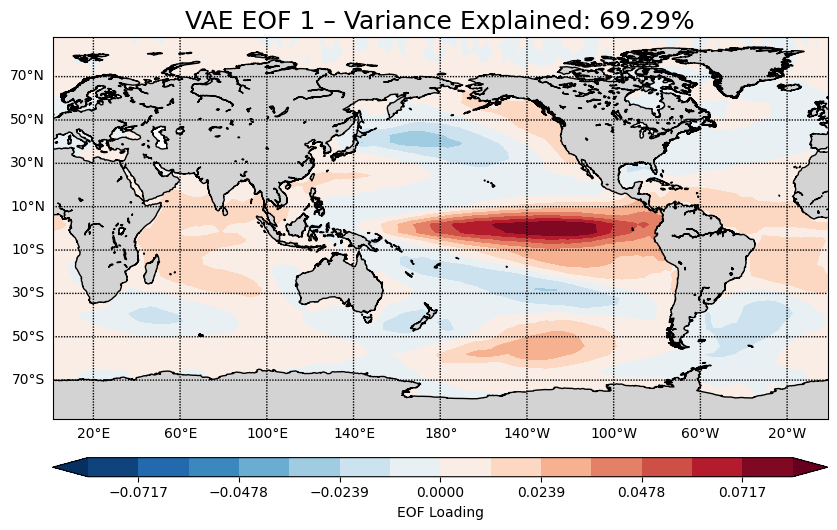

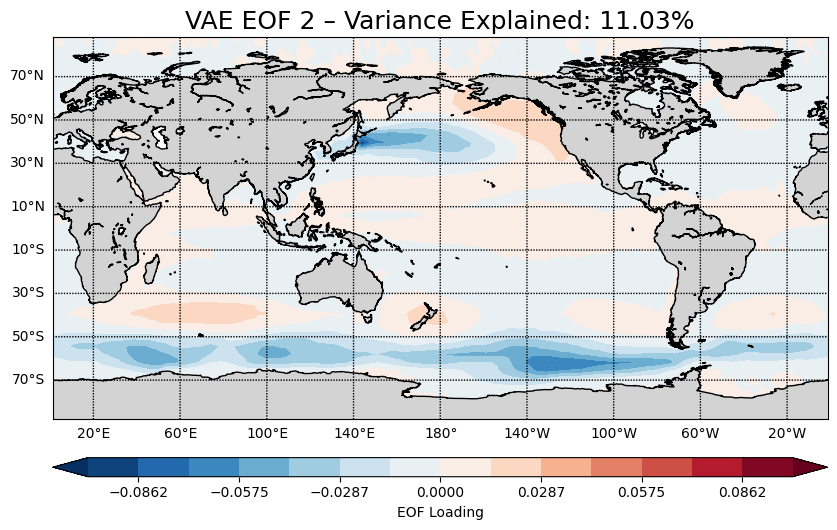

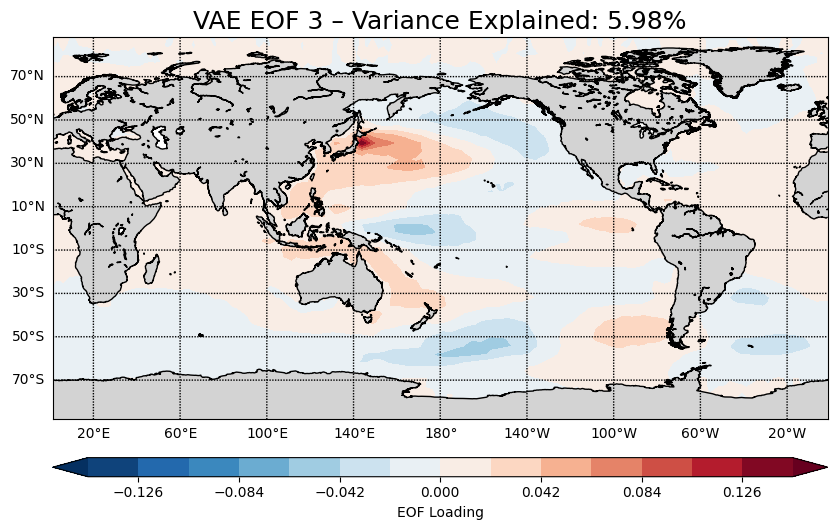

In [89]:
from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt

parallels = np.arange(-90, 90, 20)
meridians = np.arange(-180, 180, 40)

for i in range(3):

    fig = plt.figure(figsize=(10, 14))

    m = Basemap(
        projection='cyl',
        llcrnrlon=lon.min(),
        llcrnrlat=lat.min(),
        urcrnrlon=lon.max(),
        urcrnrlat=lat.max(),
        resolution='l'
    )

    x, y = m(*np.meshgrid(lon, lat))

    # symmetric range
    vmax = np.max(np.abs(eofs[i]))
    clevs = np.linspace(-vmax, vmax, 15)

    cs = m.contourf(
        x, y, eofs[i],
        clevs,
        cmap=plt.cm.RdBu_r,
        extend='both'
    )

    m.drawcoastlines()
    m.fillcontinents(color='lightgray')
    m.drawparallels(parallels, labels=[1,0,0,0])
    m.drawmeridians(meridians, labels=[0,0,0,1])

    cb = m.colorbar(cs, 'bottom', size='5%', pad='10%')
    cb.set_label("EOF Loading")

    plt.title(
        f"VAE EOF {i+1} – Variance Explained: {varfrac[i]*100:.2f}%",
        fontsize=18
    )

    plt.show()

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, fftfreq
import pylab as pl
from scipy import signal
import matplotlib.pyplot as plt
import scipy.stats


def cal_power_spect(data):
    #data=N_EP_gen#np.loadtxt('iod.txt', dtype=np.float32)
    #data=data_whole.variables['temp'][:]
    #data=data.reshape(data.shape[0],)

    nd=len(data)


    nrho=len(data)
    rho=0
    sommesup=0
    sommeinf=0
    for i in range(1,nrho):
        j=i-1
        sommesup=sommesup+(data[i]*data[j])
        sommeinf=sommeinf+((data[j]**2))

    rho=sommesup/sommeinf

    nt=len(data)

    rzero=0
    redtab=[]
    red=[]

    srho=np.sqrt(1-rho**2)

    nsim=1500

    red_sum=np.zeros((nd, nsim))
    for i in range(nsim):

        white=srho*np.random.randn(1)
        red_sum[0,i]=rho*rzero+white

        for j in range(1,nd):
            white=srho*np.random.randn(1)
            red_sum[j,i]=rho*red_sum[j-1,i]+white

    redtab.append(red_sum)

    redtab=np.array(redtab)
    redtab=redtab.reshape(nd,nsim)


    fs=1
    f, Po = signal.periodogram(data, fs, detrend='linear')

    npo=len(Po)
    Po=Po.reshape(npo,)

    Ax=np.sum(Po)/npo

    red2=[]
    specred=np.zeros((npo,nsim))

    for i in range(nsim):
        red2=redtab[:,i]
        red2m=np.sum(red2)/nd
        red2n=red2-red2m
        fs=1
        fr, Pr = signal.periodogram(red2n, fs, detrend='linear')  #detrend = linear
        npr=len(Pr)
        Pr=Pr.reshape(npr,)

        Ar=np.sum(Pr)/npr
        Pr=Pr*(Ax/Ar)
        specred[:,i]=Pr

    Mpr=0
    Mspecred=[]
    for i in range(npr):
        Mpr=specred[i,1]
        for j in range(1,nsim):
            Mpr=Mpr+specred[i,j]

        Mpr=np.sum(Mpr)/nsim
        Mspecred.append(Mpr)

    Mspecred=np.array(Mspecred)


    period_Po=1/f
    period_Pr=1/fr


    n85=round(1500*85/100)
    n90=round(1500*90/100)
    n95=round(1500*95/100)
    n99=round(1500*99/100)


    tabvecsort=np.zeros((npr,nsim))
    for i in range(npr):
        vec=specred[i,:]
        tabvecsort[i,:]=np.sort(vec)

    tabMC=np.zeros((npr,4))

    for i in range(npr):
        tabMC[i,0]=tabvecsort[i,n85]
        tabMC[i,1]=tabvecsort[i,n90]
        tabMC[i,2]=tabvecsort[i,n95]
        tabMC[i,3]=tabvecsort[i,n99]



    plot=np.zeros((Po.shape[0],3), dtype=np.float32)

    plot[:,0]=period_Po
    plot[:,1]=f*Po
    plot[:,2]=f*tabMC[:,2]
    return plot

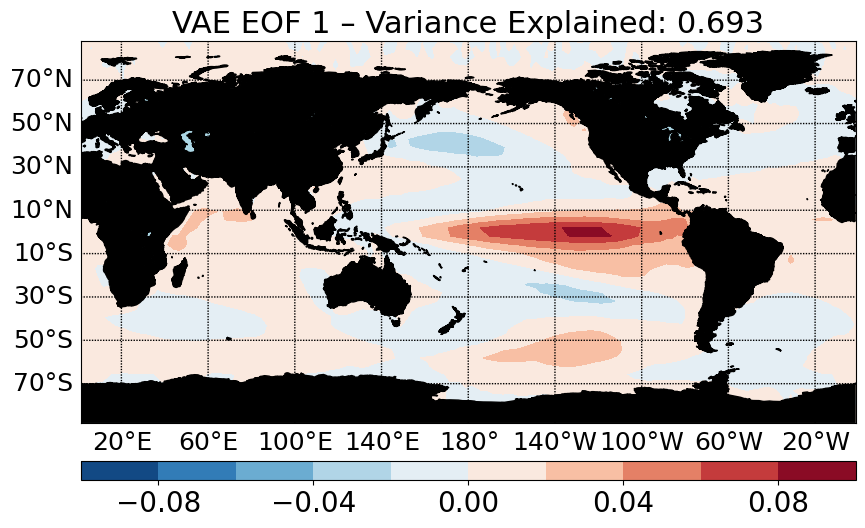

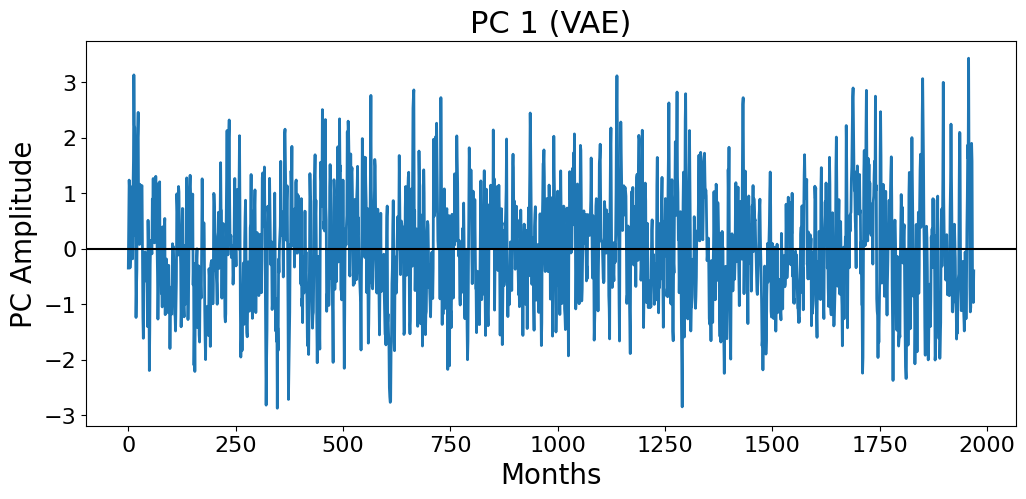

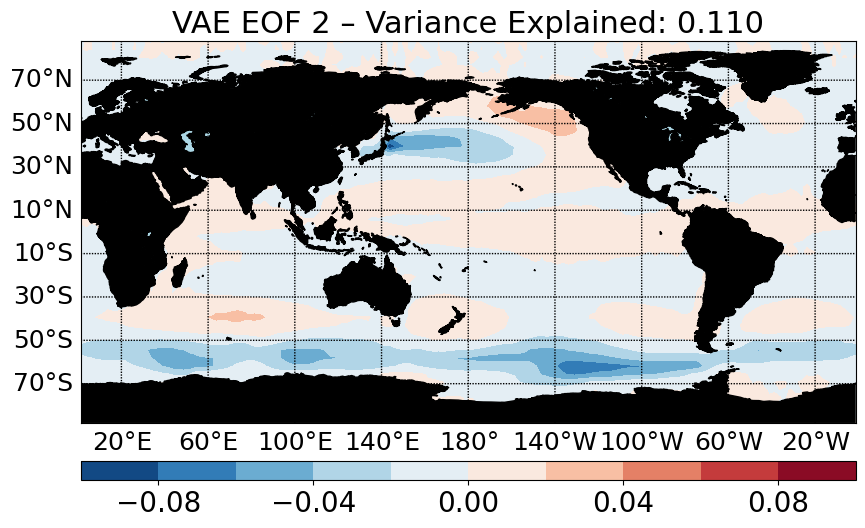

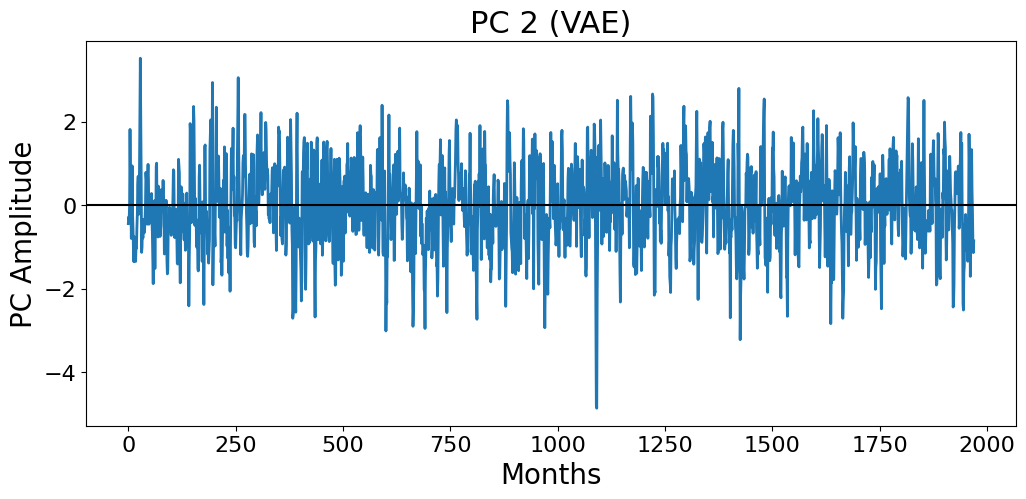

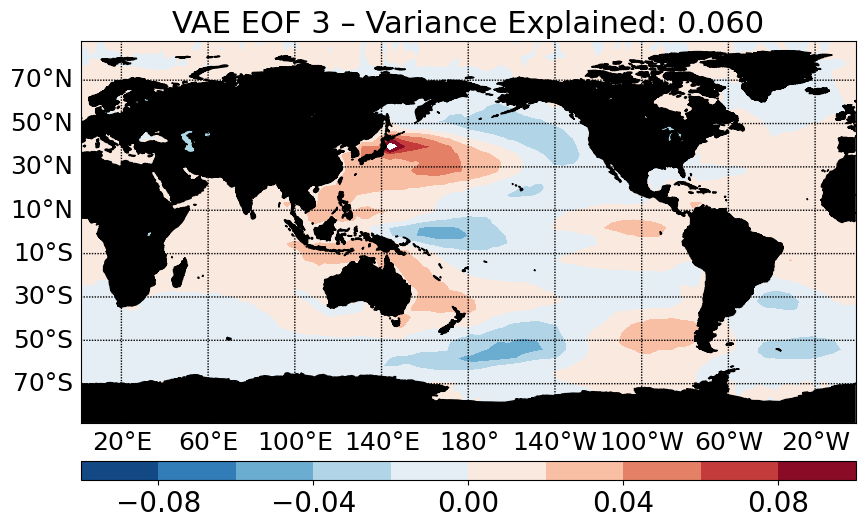

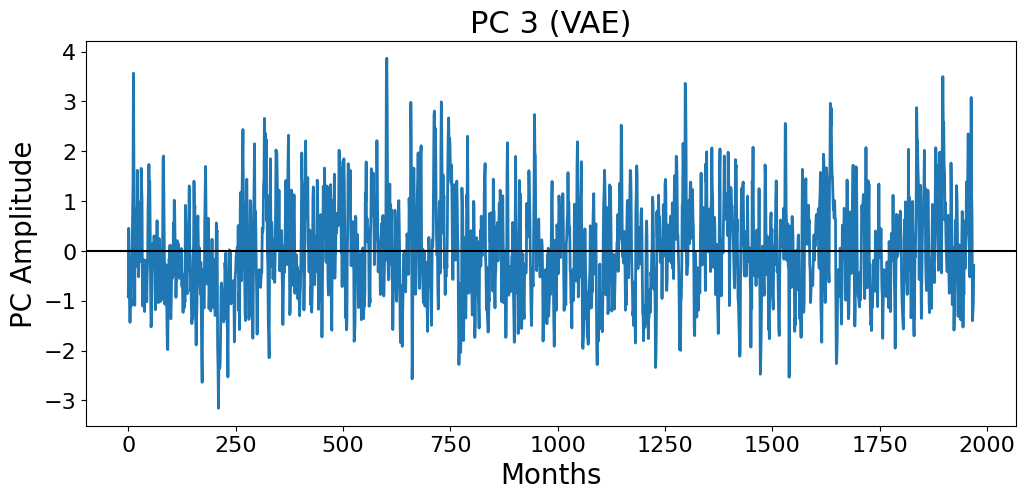

In [91]:
from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt

parallels = np.arange(-90, 90, 20)
meridians = np.arange(-180, 180, 40)

for i in range(3):

    # ---- EOF MAP ----
    fig = plt.figure(figsize=(10, 16))

    m = Basemap(
        projection='cyl',
        llcrnrlon=min(lon),
        llcrnrlat=min(lat),
        urcrnrlon=max(lon),
        urcrnrlat=max(lat),
        resolution='l'
    )

    x, y = m(*np.meshgrid(lon, lat))
    clevs = np.linspace(-0.1, 0.1, 11)

    cs = m.contourf(
        x, y, eofs[i, :, :],
        clevs, cmap=plt.cm.RdBu_r
    )

    m.drawcoastlines()
    m.fillcontinents(color='black', lake_color='lightblue')
    m.drawparallels(parallels, labels=[1,0,0,0], fontsize=18)
    m.drawmeridians(meridians, labels=[1,0,0,1], fontsize=18)

    cb = m.colorbar(cs, 'bottom', size='5%', pad='10%')
    cb.ax.tick_params(labelsize=20)

    plt.title(
        f"VAE EOF {i+1} – Variance Explained: {varfrac[i]:.3f}",
        fontsize=22
    )

    plt.show()

    # ---- PC TIME SERIES ----
    plt.figure(figsize=(12, 5))
    plt.plot(pcs[:, i], linewidth=2)
    plt.axhline(0, color='k')

    plt.xlabel("Months", fontsize=20)
    plt.ylabel("PC Amplitude", fontsize=20)
    plt.title(f"PC {i+1} (VAE)", fontsize=22)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    plt.show()

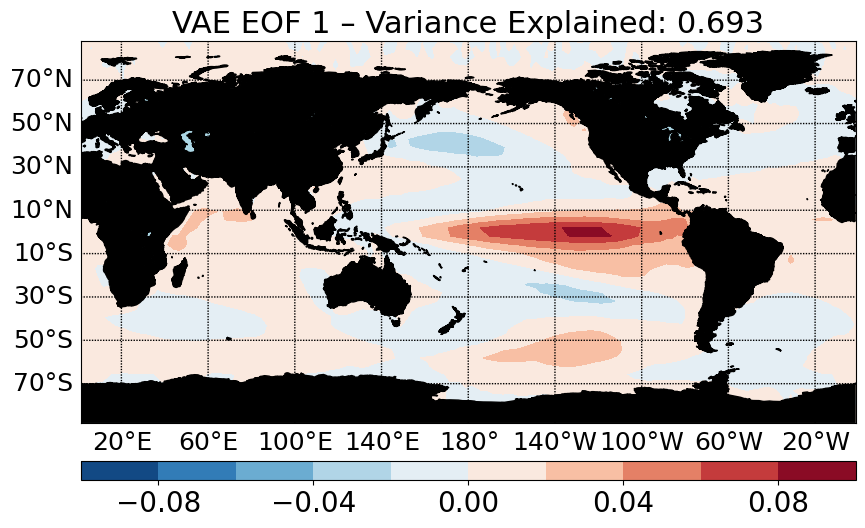

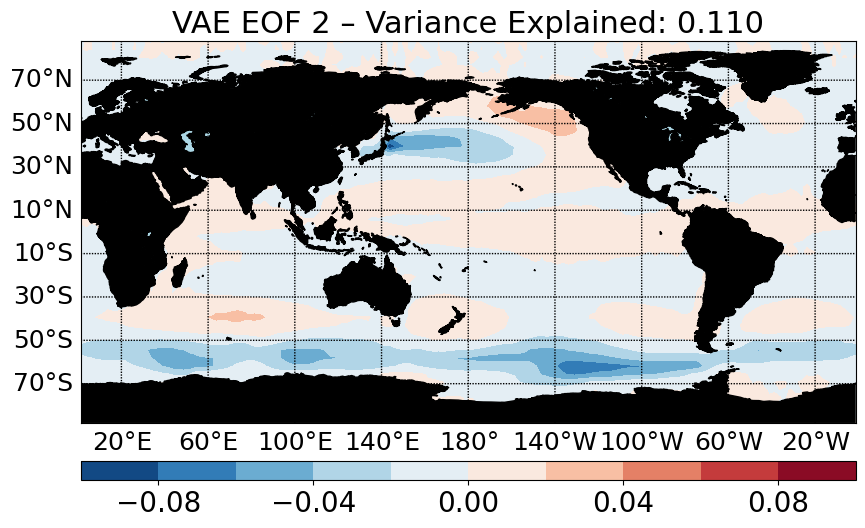

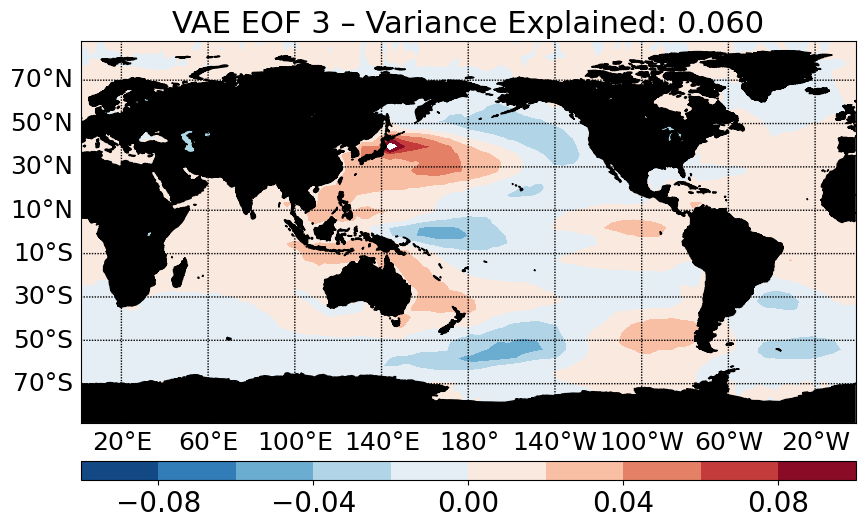

In [92]:
from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt

parallels = np.arange(-90, 90, 20)
meridians = np.arange(-180, 180, 40)

for i in range(3):

    # ---- EOF MAP ----
    fig = plt.figure(figsize=(10, 16))

    m = Basemap(
        projection='cyl',
        llcrnrlon=min(lon),
        llcrnrlat=min(lat),
        urcrnrlon=max(lon),
        urcrnrlat=max(lat),
        resolution='l'
    )

    x, y = m(*np.meshgrid(lon, lat))
    clevs = np.linspace(-0.1, 0.1, 11)

    cs = m.contourf(
        x, y, eofs[i, :, :],
        clevs, cmap=plt.cm.RdBu_r
    )

    m.drawcoastlines()
    m.fillcontinents(color='black', lake_color='lightblue')
    m.drawparallels(parallels, labels=[1,0,0,0], fontsize=18)
    m.drawmeridians(meridians, labels=[1,0,0,1], fontsize=18)

    cb = m.colorbar(cs, 'bottom', size='5%', pad='10%')
    cb.ax.tick_params(labelsize=20)

    plt.title(
        f"VAE EOF {i+1} – Variance Explained: {varfrac[i]:.3f}",
        fontsize=22
    )

    plt.show()

/tmp/ipykernel_568/89003633.py:43: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  red_sum[0,i]=rho*rzero+white
/tmp/ipykernel_568/89003633.py:47: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  red_sum[j,i]=rho*red_sum[j-1,i]+white
/tmp/ipykernel_568/89003633.py:92: RuntimeWarning: divide by zero encountered in divide
  period_Po=1/f
/tmp/ipykernel_568/89003633.py:93: RuntimeWarning: divide by zero encountered in divide
  period_Pr=1/fr


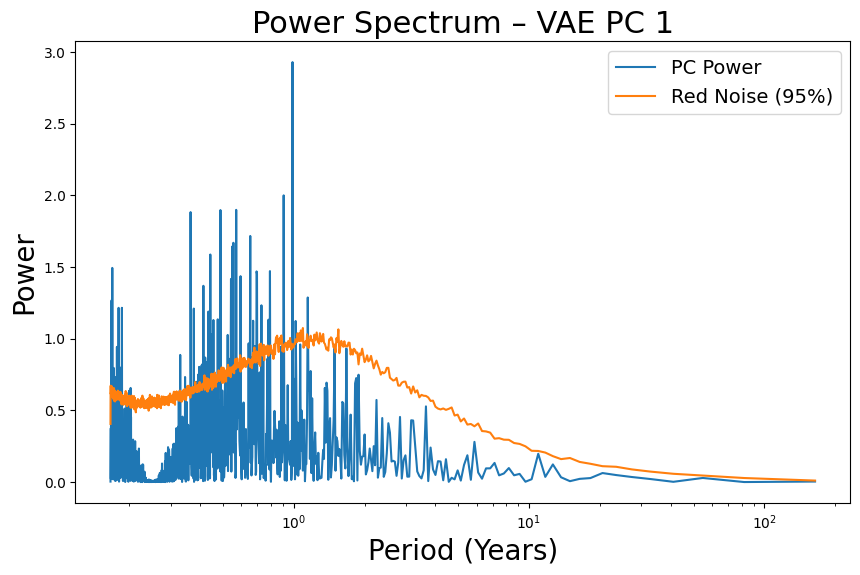

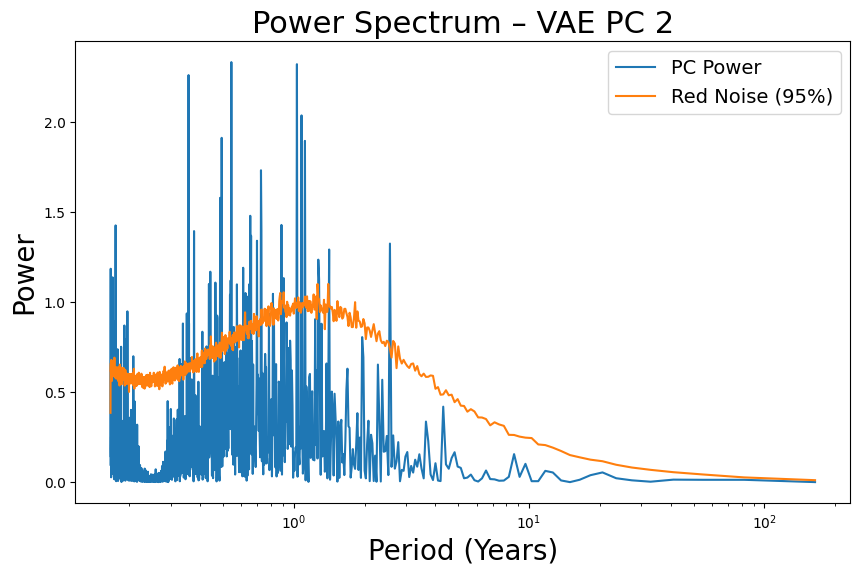

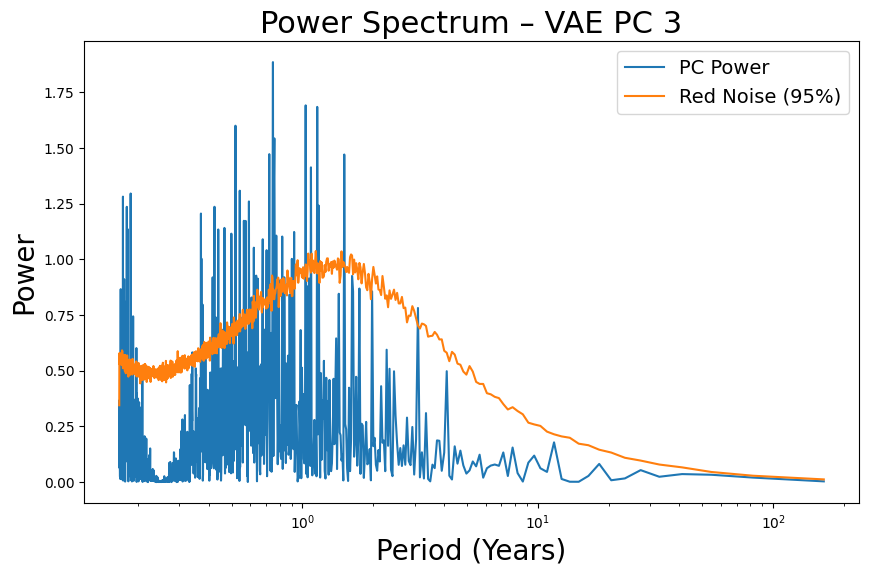

In [93]:
for i in range(3):
    plot = cal_power_spect(pcs[:, i])

    plt.figure(figsize=(10, 6))
    plt.plot(plot[:, 0] / 12, plot[:, 1], label="PC Power")
    plt.plot(plot[:, 0] / 12, plot[:, 2], label="Red Noise (95%)")
    plt.xscale("log")
    plt.xlabel("Period (Years)", fontsize=20)
    plt.ylabel("Power", fontsize=20)
    plt.legend(fontsize=14)
    plt.title(f"Power Spectrum – VAE PC {i+1}", fontsize=22)

    plt.show()

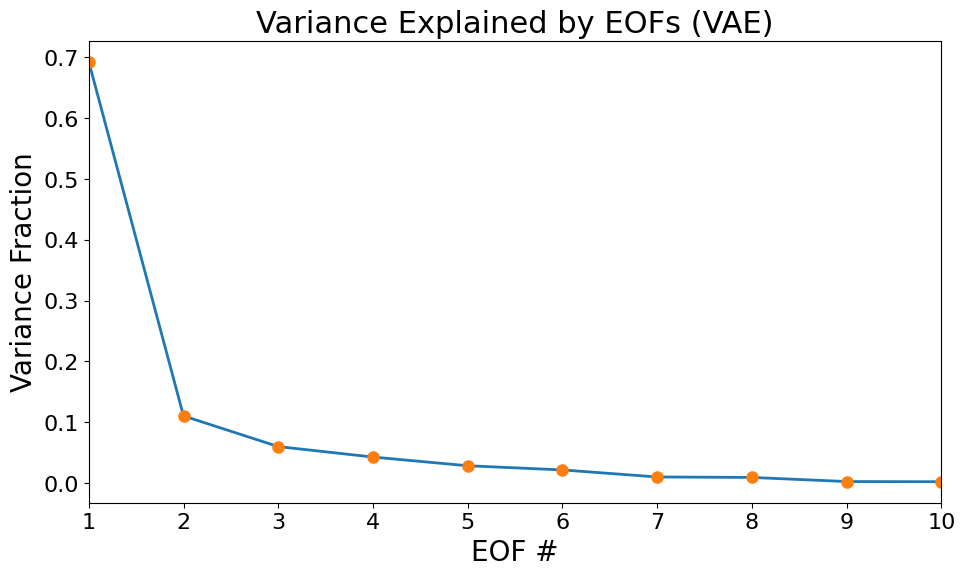

In [94]:
plt.figure(figsize=(11, 6))

eof_num = np.arange(1, 11)

plt.plot(eof_num, varfrac[:10], linewidth=2)
plt.plot(
    eof_num, varfrac[:10],
    linestyle='None', marker='o',
    markersize=8
)

plt.xlabel("EOF #", fontsize=20)
plt.ylabel("Variance Fraction", fontsize=20)
plt.title("Variance Explained by EOFs (VAE)", fontsize=22)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlim(1, 10)

plt.show()

In [95]:
ens_id = 0   # choose ensemble index

single_member = vae_anom_3mo["sst"].isel(ensemble=ens_id).values

In [96]:
valid = ~np.all(np.isnan(single_member), axis=(1,2))
Data = single_member[valid]

In [97]:
print(single_member.shape)
print(Data.shape)

(199, 48, 144)
(197, 48, 144)


In [98]:
lat = vae_anom_3mo.lat.values
coslat = np.cos(np.deg2rad(lat))
wgts = np.sqrt(coslat)[:, np.newaxis]

In [99]:
from eofs.standard import Eof

solver = Eof(Data, weights=wgts)

eofs = solver.eofs()              # (EOF, lat, lon)
pcs = solver.pcs(pcscaling=1)     # (time, EOF)
varfrac = solver.varianceFraction()
lambdas = solver.eigenvalues()

In [100]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, fftfreq
import pylab as pl
from scipy import signal
import matplotlib.pyplot as plt
import scipy.stats


def cal_power_spect(data):
    #data=N_EP_gen#np.loadtxt('iod.txt', dtype=np.float32)
    #data=data_whole.variables['temp'][:]
    #data=data.reshape(data.shape[0],)

    nd=len(data)


    nrho=len(data)
    rho=0
    sommesup=0
    sommeinf=0
    for i in range(1,nrho):
        j=i-1
        sommesup=sommesup+(data[i]*data[j])
        sommeinf=sommeinf+((data[j]**2))

    rho=sommesup/sommeinf

    nt=len(data)

    rzero=0
    redtab=[]
    red=[]

    srho=np.sqrt(1-rho**2)

    nsim=1500

    red_sum=np.zeros((nd, nsim))
    for i in range(nsim):

        white=srho*np.random.randn(1)
        red_sum[0,i]=rho*rzero+white

        for j in range(1,nd):
            white=srho*np.random.randn(1)
            red_sum[j,i]=rho*red_sum[j-1,i]+white

    redtab.append(red_sum)

    redtab=np.array(redtab)
    redtab=redtab.reshape(nd,nsim)


    fs=1
    f, Po = signal.periodogram(data, fs, detrend='linear')

    npo=len(Po)
    Po=Po.reshape(npo,)

    Ax=np.sum(Po)/npo

    red2=[]
    specred=np.zeros((npo,nsim))

    for i in range(nsim):
        red2=redtab[:,i]
        red2m=np.sum(red2)/nd
        red2n=red2-red2m
        fs=1
        fr, Pr = signal.periodogram(red2n, fs, detrend='linear')  #detrend = linear
        npr=len(Pr)
        Pr=Pr.reshape(npr,)

        Ar=np.sum(Pr)/npr
        Pr=Pr*(Ax/Ar)
        specred[:,i]=Pr

    Mpr=0
    Mspecred=[]
    for i in range(npr):
        Mpr=specred[i,1]
        for j in range(1,nsim):
            Mpr=Mpr+specred[i,j]

        Mpr=np.sum(Mpr)/nsim
        Mspecred.append(Mpr)

    Mspecred=np.array(Mspecred)


    period_Po=1/f
    period_Pr=1/fr


    n85=round(1500*85/100)
    n90=round(1500*90/100)
    n95=round(1500*95/100)
    n99=round(1500*99/100)


    tabvecsort=np.zeros((npr,nsim))
    for i in range(npr):
        vec=specred[i,:]
        tabvecsort[i,:]=np.sort(vec)

    tabMC=np.zeros((npr,4))

    for i in range(npr):
        tabMC[i,0]=tabvecsort[i,n85]
        tabMC[i,1]=tabvecsort[i,n90]
        tabMC[i,2]=tabvecsort[i,n95]
        tabMC[i,3]=tabvecsort[i,n99]



    plot=np.zeros((Po.shape[0],3), dtype=np.float32)

    plot[:,0]=period_Po
    plot[:,1]=f*Po
    plot[:,2]=f*tabMC[:,2]
    return plot

In [101]:
ori_data = ori_stacked.values

valid_idx = ~np.all(np.isnan(vae_data), axis=(1, 2))
Data = ori_data[valid_idx]

In [102]:
lat = ori_anom_3mo.lat.values
lon = ori_anom_3mo.lon.values

coslat = np.cos(np.deg2rad(lat))
wgts = np.sqrt(coslat)[:, np.newaxis]

from eofs.standard import Eof

solver = Eof(Data, weights=wgts)

eofs = solver.eofs(neofs=10)
pcs = solver.pcs(npcs=10, pcscaling=1)
varfrac = solver.varianceFraction()
lambdas = solver.eigenvalues()

for e in range(vae_anom_3mo.sizes["ensemble"]):

    single_member = vae_anom_3mo["sst"].isel(ensemble=e).values

    valid = ~np.all(np.isnan(single_member), axis=(1,2))
    single_member = single_member[valid]

    solver = Eof(single_member, weights=wgts)
    pcs_single = solver.pcs(npcs=1, pcscaling=1)

In [103]:
ens_id = 0   # choose ensemble index
single_member = ori_anom_3mo["sst"].isel(ensemble=ens_id).values
valid = ~np.all(np.isnan(single_member), axis=(1,2))
Data = single_member[valid]
lat = ori_anom_3mo.lat.values
coslat = np.cos(np.deg2rad(lat))
wgts = np.sqrt(coslat)[:, np.newaxis]
from eofs.standard import Eof

solver = Eof(Data, weights=wgts)

eofs = solver.eofs()              # (EOF, lat, lon)
pcs = solver.pcs(pcscaling=1)     # (time, EOF)
varfrac = solver.varianceFraction()
lambdas = solver.eigenvalues()

In [104]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, fftfreq
import pylab as pl
from scipy import signal
import matplotlib.pyplot as plt
import scipy.stats


def cal_power_spect(data):
    #data=N_EP_gen#np.loadtxt('iod.txt', dtype=np.float32)
    #data=data_whole.variables['temp'][:]
    #data=data.reshape(data.shape[0],)

    nd=len(data)


    nrho=len(data)
    rho=0
    sommesup=0
    sommeinf=0
    for i in range(1,nrho):
        j=i-1
        sommesup=sommesup+(data[i]*data[j])
        sommeinf=sommeinf+((data[j]**2))

    rho=sommesup/sommeinf

    nt=len(data)

    rzero=0
    redtab=[]
    red=[]

    srho=np.sqrt(1-rho**2)

    nsim=1500

    red_sum=np.zeros((nd, nsim))
    for i in range(nsim):

        white=srho*np.random.randn(1)
        red_sum[0,i]=rho*rzero+white

        for j in range(1,nd):
            white=srho*np.random.randn(1)
            red_sum[j,i]=rho*red_sum[j-1,i]+white

    redtab.append(red_sum)

    redtab=np.array(redtab)
    redtab=redtab.reshape(nd,nsim)


    fs=1
    f, Po = signal.periodogram(data, fs, detrend='linear')

    npo=len(Po)
    Po=Po.reshape(npo,)

    Ax=np.sum(Po)/npo

    red2=[]
    specred=np.zeros((npo,nsim))

    for i in range(nsim):
        red2=redtab[:,i]
        red2m=np.sum(red2)/nd
        red2n=red2-red2m
        fs=1
        fr, Pr = signal.periodogram(red2n, fs, detrend='linear')  #detrend = linear
        npr=len(Pr)
        Pr=Pr.reshape(npr,)

        Ar=np.sum(Pr)/npr
        Pr=Pr*(Ax/Ar)
        specred[:,i]=Pr

    Mpr=0
    Mspecred=[]
    for i in range(npr):
        Mpr=specred[i,1]
        for j in range(1,nsim):
            Mpr=Mpr+specred[i,j]

        Mpr=np.sum(Mpr)/nsim
        Mspecred.append(Mpr)

    Mspecred=np.array(Mspecred)


    period_Po=1/f
    period_Pr=1/fr


    n85=round(1500*85/100)
    n90=round(1500*90/100)
    n95=round(1500*95/100)
    n99=round(1500*99/100)


    tabvecsort=np.zeros((npr,nsim))
    for i in range(npr):
        vec=specred[i,:]
        tabvecsort[i,:]=np.sort(vec)

    tabMC=np.zeros((npr,4))

    for i in range(npr):
        tabMC[i,0]=tabvecsort[i,n85]
        tabMC[i,1]=tabvecsort[i,n90]
        tabMC[i,2]=tabvecsort[i,n95]
        tabMC[i,3]=tabvecsort[i,n99]



    plot=np.zeros((Po.shape[0],3), dtype=np.float32)

    plot[:,0]=period_Po
    plot[:,1]=f*Po
    plot[:,2]=f*tabMC[:,2]
    return plot

In [105]:
ori_data = ori_stacked.values

valid_idx = ~np.all(np.isnan(ori_data), axis=(1, 2))
Data = ori_data[valid_idx]

In [106]:
lat = ori_anom_3mo.lat.values
lon = ori_anom_3mo.lon.values

coslat = np.cos(np.deg2rad(lat))
wgts = np.sqrt(coslat)[:, np.newaxis]

from eofs.standard import Eof

solver = Eof(Data, weights=wgts)

eofs = solver.eofs(neofs=10)
pcs = solver.pcs(npcs=10, pcscaling=1)
varfrac = solver.varianceFraction()
lambdas = solver.eigenvalues()

for e in range(ori_anom_3mo.sizes["ensemble"]):

    single_member = ori_anom_3mo["sst"].isel(ensemble=e).values

    valid = ~np.all(np.isnan(single_member), axis=(1,2))
    single_member = single_member[valid]

    solver = Eof(single_member, weights=wgts)
    pcs_single = solver.pcs(npcs=1, pcscaling=1)

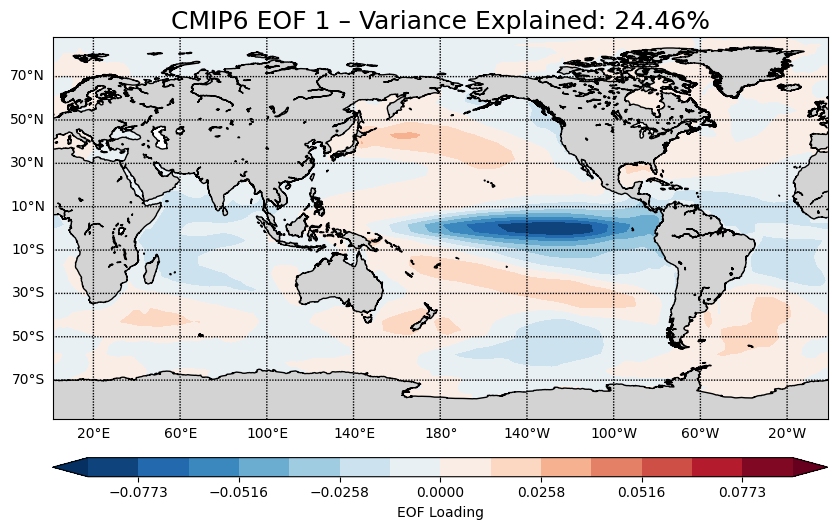

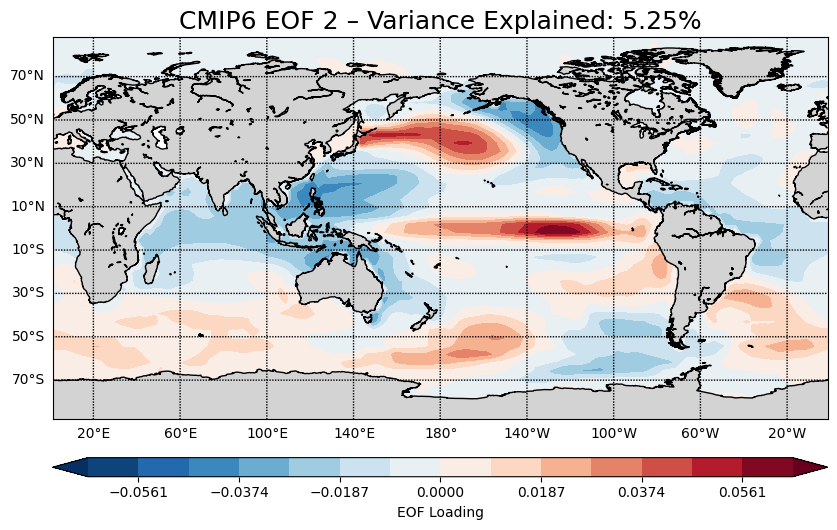

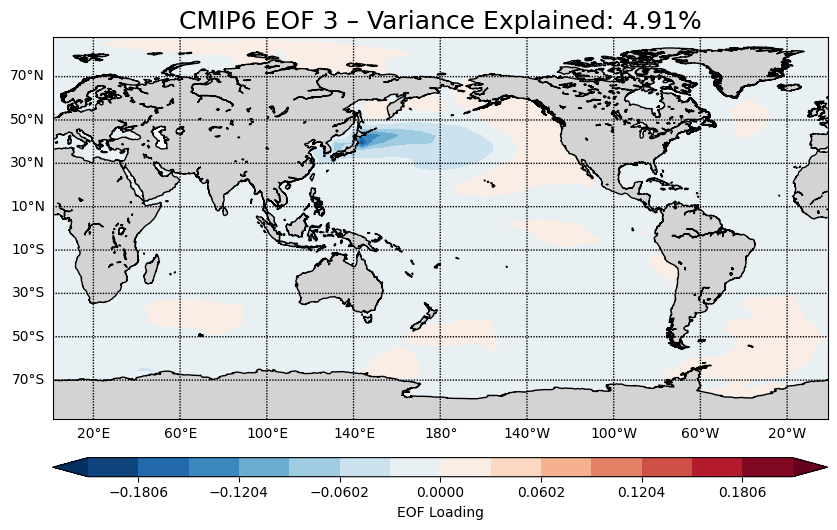

In [107]:
from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt

parallels = np.arange(-90, 90, 20)
meridians = np.arange(-180, 180, 40)

for i in range(3):

    fig = plt.figure(figsize=(10, 14))

    m = Basemap(
        projection='cyl',
        llcrnrlon=lon.min(),
        llcrnrlat=lat.min(),
        urcrnrlon=lon.max(),
        urcrnrlat=lat.max(),
        resolution='l'
    )

    x, y = m(*np.meshgrid(lon, lat))

    # symmetric range
    vmax = np.max(np.abs(eofs[i]))
    clevs = np.linspace(-vmax, vmax, 15)

    cs = m.contourf(
        x, y, eofs[i],
        clevs,
        cmap=plt.cm.RdBu_r,
        extend='both'
    )

    m.drawcoastlines()
    m.fillcontinents(color='lightgray')
    m.drawparallels(parallels, labels=[1,0,0,0])
    m.drawmeridians(meridians, labels=[0,0,0,1])

    cb = m.colorbar(cs, 'bottom', size='5%', pad='10%')
    cb.set_label("EOF Loading")

    plt.title(
        f"CMIP6 EOF {i+1} – Variance Explained: {varfrac[i]*100:.2f}%",
        fontsize=18
    )

    plt.show()

In [108]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, fftfreq
import pylab as pl
from scipy import signal
import matplotlib.pyplot as plt
import scipy.stats


def cal_power_spect(data):
    #data=N_EP_gen#np.loadtxt('iod.txt', dtype=np.float32)
    #data=data_whole.variables['temp'][:]
    #data=data.reshape(data.shape[0],)

    nd=len(data)


    nrho=len(data)
    rho=0
    sommesup=0
    sommeinf=0
    for i in range(1,nrho):
        j=i-1
        sommesup=sommesup+(data[i]*data[j])
        sommeinf=sommeinf+((data[j]**2))

    rho=sommesup/sommeinf

    nt=len(data)

    rzero=0
    redtab=[]
    red=[]

    srho=np.sqrt(1-rho**2)

    nsim=1500

    red_sum=np.zeros((nd, nsim))
    for i in range(nsim):

        white=srho*np.random.randn(1)
        red_sum[0,i]=rho*rzero+white

        for j in range(1,nd):
            white=srho*np.random.randn(1)
            red_sum[j,i]=rho*red_sum[j-1,i]+white

    redtab.append(red_sum)

    redtab=np.array(redtab)
    redtab=redtab.reshape(nd,nsim)


    fs=1
    f, Po = signal.periodogram(data, fs, detrend='linear')

    npo=len(Po)
    Po=Po.reshape(npo,)

    Ax=np.sum(Po)/npo

    red2=[]
    specred=np.zeros((npo,nsim))

    for i in range(nsim):
        red2=redtab[:,i]
        red2m=np.sum(red2)/nd
        red2n=red2-red2m
        fs=1
        fr, Pr = signal.periodogram(red2n, fs, detrend='linear')  #detrend = linear
        npr=len(Pr)
        Pr=Pr.reshape(npr,)

        Ar=np.sum(Pr)/npr
        Pr=Pr*(Ax/Ar)
        specred[:,i]=Pr

    Mpr=0
    Mspecred=[]
    for i in range(npr):
        Mpr=specred[i,1]
        for j in range(1,nsim):
            Mpr=Mpr+specred[i,j]

        Mpr=np.sum(Mpr)/nsim
        Mspecred.append(Mpr)

    Mspecred=np.array(Mspecred)


    period_Po=1/f
    period_Pr=1/fr


    n85=round(1500*85/100)
    n90=round(1500*90/100)
    n95=round(1500*95/100)
    n99=round(1500*99/100)


    tabvecsort=np.zeros((npr,nsim))
    for i in range(npr):
        vec=specred[i,:]
        tabvecsort[i,:]=np.sort(vec)

    tabMC=np.zeros((npr,4))

    for i in range(npr):
        tabMC[i,0]=tabvecsort[i,n85]
        tabMC[i,1]=tabvecsort[i,n90]
        tabMC[i,2]=tabvecsort[i,n95]
        tabMC[i,3]=tabvecsort[i,n99]



    plot=np.zeros((Po.shape[0],3), dtype=np.float32)

    plot[:,0]=period_Po
    plot[:,1]=f*Po
    plot[:,2]=f*tabMC[:,2]
    return plot

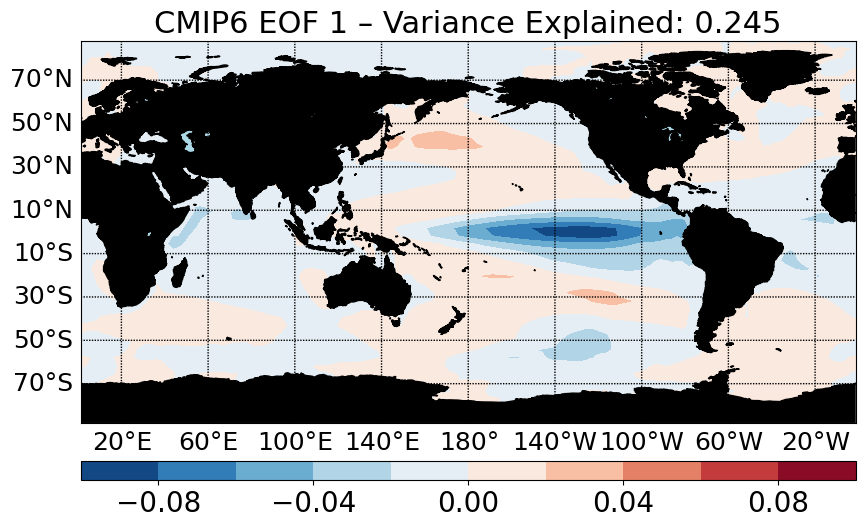

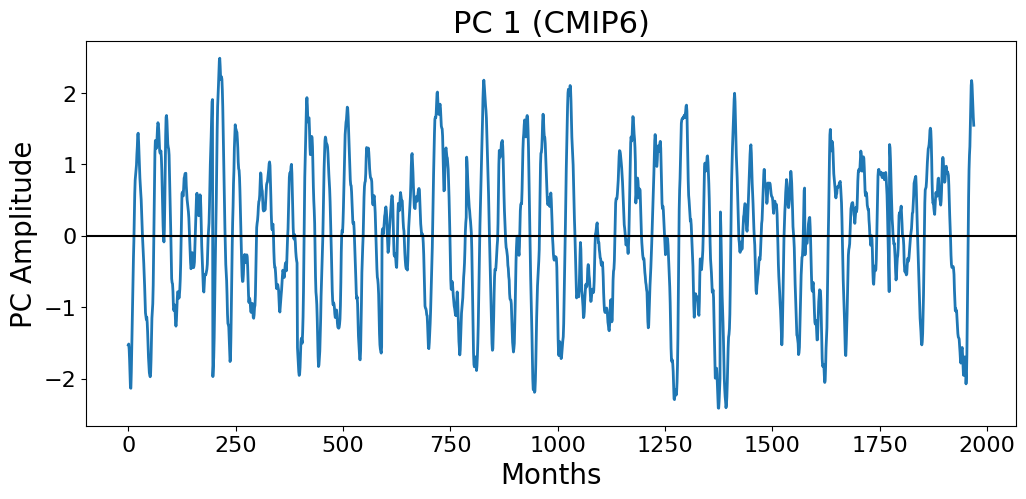

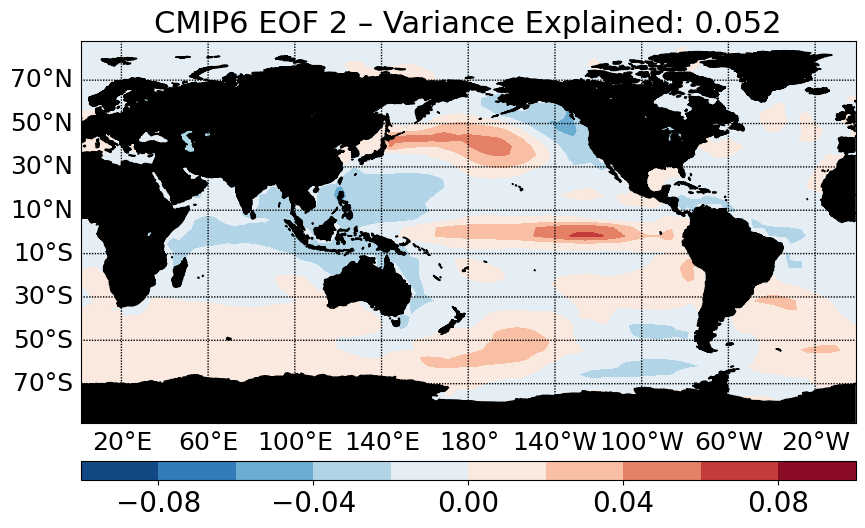

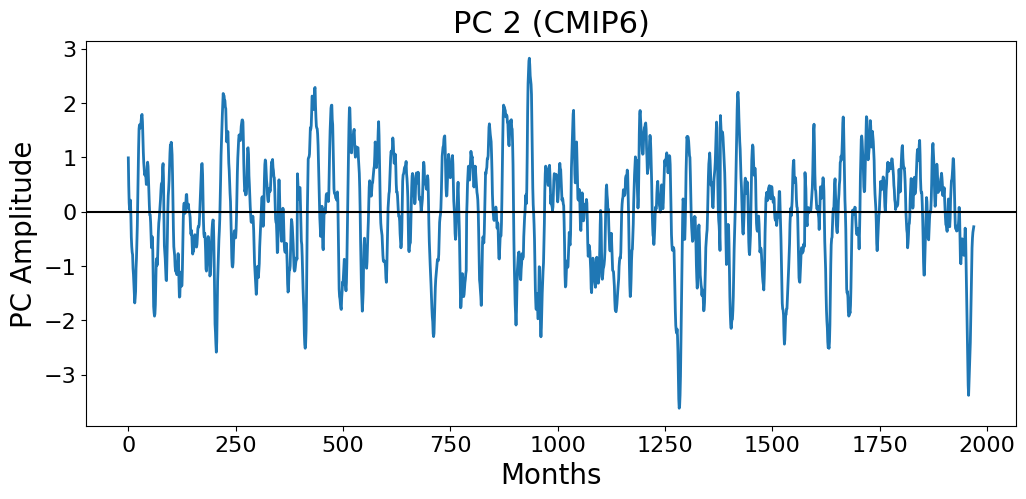

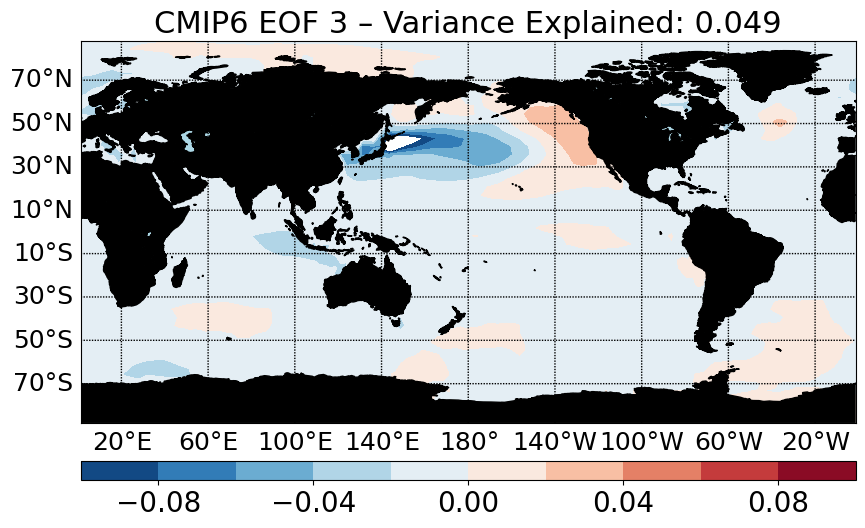

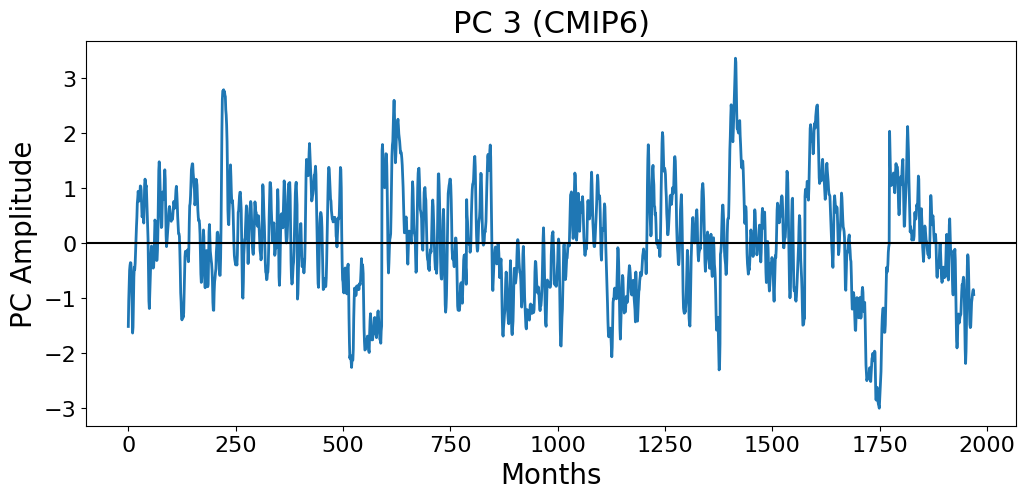

In [109]:
from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt

parallels = np.arange(-90, 90, 20)
meridians = np.arange(-180, 180, 40)

for i in range(3):

    # ---- EOF MAP ----
    fig = plt.figure(figsize=(10, 16))

    m = Basemap(
        projection='cyl',
        llcrnrlon=min(lon),
        llcrnrlat=min(lat),
        urcrnrlon=max(lon),
        urcrnrlat=max(lat),
        resolution='l'
    )

    x, y = m(*np.meshgrid(lon, lat))
    clevs = np.linspace(-0.1, 0.1, 11)

    cs = m.contourf(
        x, y, eofs[i, :, :],
        clevs, cmap=plt.cm.RdBu_r
    )

    m.drawcoastlines()
    m.fillcontinents(color='black', lake_color='lightblue')
    m.drawparallels(parallels, labels=[1,0,0,0], fontsize=18)
    m.drawmeridians(meridians, labels=[1,0,0,1], fontsize=18)

    cb = m.colorbar(cs, 'bottom', size='5%', pad='10%')
    cb.ax.tick_params(labelsize=20)

    plt.title(
        f"CMIP6 EOF {i+1} – Variance Explained: {varfrac[i]:.3f}",
        fontsize=22
    )

    plt.show()

    # ---- PC TIME SERIES ----
    plt.figure(figsize=(12, 5))
    plt.plot(pcs[:, i], linewidth=2)
    plt.axhline(0, color='k')

    plt.xlabel("Months", fontsize=20)
    plt.ylabel("PC Amplitude", fontsize=20)
    plt.title(f"PC {i+1} (CMIP6)", fontsize=22)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    plt.show()

/tmp/ipykernel_568/89003633.py:43: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  red_sum[0,i]=rho*rzero+white
/tmp/ipykernel_568/89003633.py:47: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  red_sum[j,i]=rho*red_sum[j-1,i]+white
/tmp/ipykernel_568/89003633.py:92: RuntimeWarning: divide by zero encountered in divide
  period_Po=1/f
/tmp/ipykernel_568/89003633.py:93: RuntimeWarning: divide by zero encountered in divide
  period_Pr=1/fr


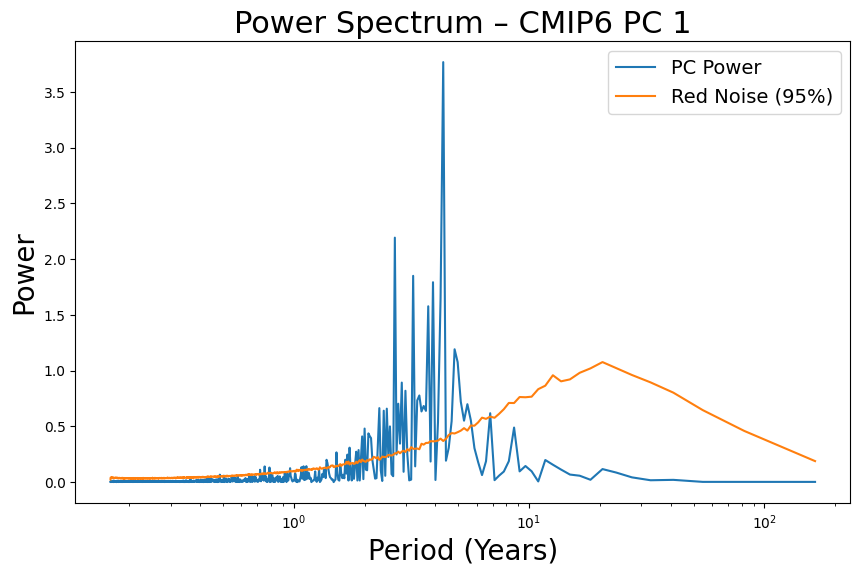

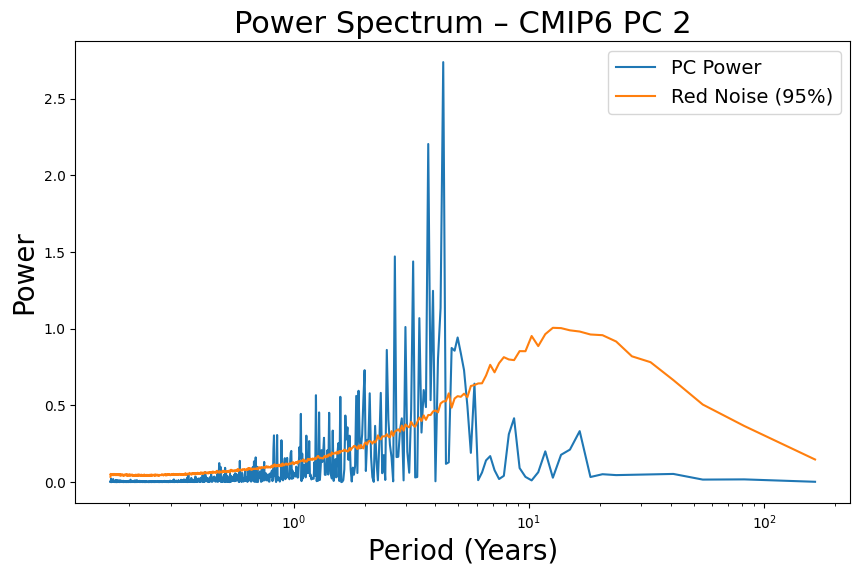

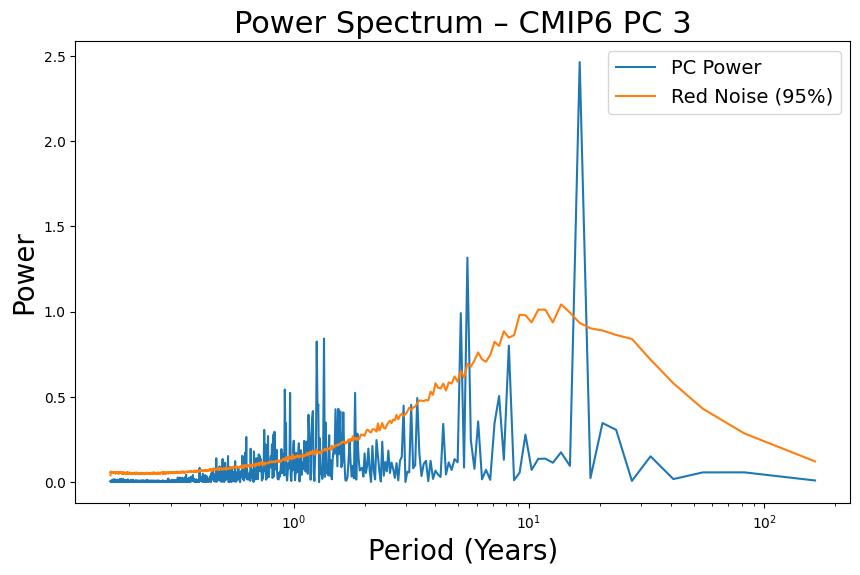

In [110]:
for i in range(3):
    plot = cal_power_spect(pcs[:, i])

    plt.figure(figsize=(10, 6))
    plt.plot(plot[:, 0] / 12, plot[:, 1], label="PC Power")
    plt.plot(plot[:, 0] / 12, plot[:, 2], label="Red Noise (95%)")

    plt.xscale("log")
    plt.xlabel("Period (Years)", fontsize=20)
    plt.ylabel("Power", fontsize=20)
    plt.legend(fontsize=14)
    plt.title(f"Power Spectrum – CMIP6 PC {i+1}", fontsize=22)

    plt.show()

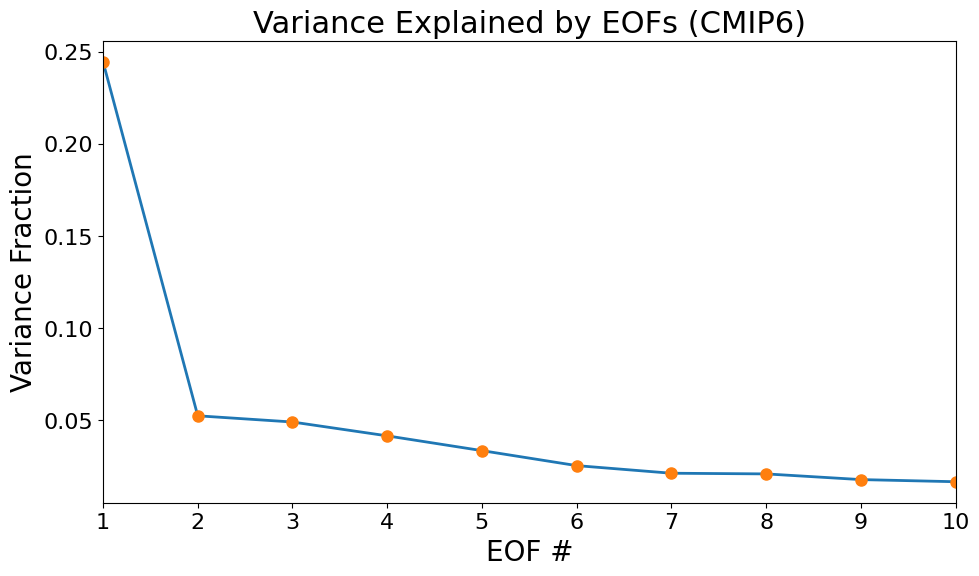

In [111]:
plt.figure(figsize=(11, 6))

eof_num = np.arange(1, 11)

plt.plot(eof_num, varfrac[:10], linewidth=2)
plt.plot(
    eof_num, varfrac[:10],
    linestyle='None', marker='o',
    markersize=8
)

plt.xlabel("EOF #", fontsize=20)
plt.ylabel("Variance Fraction", fontsize=20)
plt.title("Variance Explained by EOFs (CMIP6)", fontsize=22)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlim(1, 10)
plt.show()

In [112]:
import xarray as xr

load_path = "/content/drive/MyDrive/SST_Data/VAE_generated_samples.nc"

vae_anom_ds = xr.open_dataset(load_path)

print(vae_anom_ds)

<xarray.Dataset> Size: 55MB
Dimensions:   (ensemble: 10, time: 199, lat: 48, lon: 144)
Coordinates:
  * ensemble  (ensemble) int64 80B 0 1 2 3 4 5 6 7 8 9
  * time      (time) int64 2kB 0 1 2 3 4 5 6 7 ... 192 193 194 195 196 197 198
  * lat       (lat) float64 384B -88.12 -84.38 -80.62 ... 80.62 84.38 88.12
  * lon       (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
Data variables:
    sst       (ensemble, time, lat, lon) float32 55MB ...


In [113]:
save_path_ori = "/content/drive/MyDrive/SST_Data/CMIP6_original_samples.nc"

ori_anom_ds.to_netcdf(save_path_ori)

print("Original samples saved successfully!")

Original samples saved successfully!


In [114]:
import xarray as xr

load_path_ori = "/content/drive/MyDrive/SST_Data/CMIP6_original_samples.nc"

ori_anom_ds = xr.open_dataset(load_path_ori)

print(ori_anom_ds)

<xarray.Dataset> Size: 110MB
Dimensions:   (ensemble: 10, time: 199, lat: 48, lon: 144)
Coordinates:
  * ensemble  (ensemble) int64 80B 0 1 2 3 4 5 6 7 8 9
  * time      (time) int64 2kB 0 1 2 3 4 5 6 7 ... 192 193 194 195 196 197 198
  * lat       (lat) float64 384B -88.12 -84.38 -80.62 ... 80.62 84.38 88.12
  * lon       (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
Data variables:
    sst       (ensemble, time, lat, lon) float64 110MB ...


In [115]:
import numpy as np

vae = vae_anom_ds["sst"].values
ori = ori_anom_ds["sst"].values

print("Same shape:", vae.shape == ori.shape)

print("Max absolute difference:",
      np.max(np.abs(vae - ori)))

print("Mean absolute difference:",
      np.mean(np.abs(vae - ori)))

print("Are arrays exactly equal:",
      np.array_equal(vae, ori))

Same shape: True
Max absolute difference: 8.708057858445788
Mean absolute difference: 0.2887591644166485
Are arrays exactly equal: False


In [116]:
obs_anom_ds = xr.open_dataset(
    "/content/drive/MyDrive/SST_Data/COBE_SST_resize.nc",
    decode_times=False
)

In [117]:
print("VAE Dataset:")
print(vae_anom_ds)
print()

print("CMIP6 Dataset:")
print(ori_anom_ds)
print()

print("OBS Dataset:")
print(obs_anom_ds)

VAE Dataset:
<xarray.Dataset> Size: 55MB
Dimensions:   (ensemble: 10, time: 199, lat: 48, lon: 144)
Coordinates:
  * ensemble  (ensemble) int64 80B 0 1 2 3 4 5 6 7 8 9
  * time      (time) int64 2kB 0 1 2 3 4 5 6 7 ... 192 193 194 195 196 197 198
  * lat       (lat) float64 384B -88.12 -84.38 -80.62 ... 80.62 84.38 88.12
  * lon       (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
Data variables:
    sst       (ensemble, time, lat, lon) float32 55MB -0.02868 ... -0.008695

CMIP6 Dataset:
<xarray.Dataset> Size: 110MB
Dimensions:   (ensemble: 10, time: 199, lat: 48, lon: 144)
Coordinates:
  * ensemble  (ensemble) int64 80B 0 1 2 3 4 5 6 7 8 9
  * time      (time) int64 2kB 0 1 2 3 4 5 6 7 ... 192 193 194 195 196 197 198
  * lat       (lat) float64 384B -88.12 -84.38 -80.62 ... 80.62 84.38 88.12
  * lon       (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
Data variables:
    sst       (ensemble, time, lat, lon) float64 110MB 0.0 0.0 ... -0.006414

OBS

In [118]:
print(obs_anom_ds.time[0].values)
print(obs_anom_ds.time[-1].values)
print(len(obs_anom_ds.time))

-14975.0
48882.0
2099


In [119]:
print(obs_anom_ds.time.attrs)

{'standard_name': 'time', 'long_name': 'Time', 'units': 'days since 1891-1-1 00:00:00', 'calendar': 'standard', 'axis': 'T'}


In [120]:
import pandas as pd

test_time = pd.date_range(
    start="1990-01-01",
    periods=199,
    freq="MS"
)

vae_anom_ds = vae_anom_ds.assign_coords(time=test_time)
ori_anom_ds = ori_anom_ds.assign_coords(time=test_time)

In [121]:
obs_anom_ds = xr.open_dataset(
    "/content/drive/MyDrive/SST_Data/COBE_SST_resize.nc",
    decode_times=True
)

print(obs_anom_ds.time.dtype)
print(obs_anom_ds.time.values[:5])

datetime64[ns]
['1850-01-01T00:00:00.000000000' '1850-02-01T00:00:00.000000000'
 '1850-03-01T00:00:00.000000000' '1850-04-01T00:00:00.000000000'
 '1850-05-01T00:00:00.000000000']


In [122]:
import pandas as pd

# Construct correct test time axis
test_time = pd.date_range(
    start="1990-01-01",
    periods=199,
    freq="MS"
)

# Assign to VAE & CMIP6
vae_anom_ds = vae_anom_ds.assign_coords(time=test_time)
ori_anom_ds = ori_anom_ds.assign_coords(time=test_time)

print("VAE time range:", vae_anom_ds.time[0].values,
      "→", vae_anom_ds.time[-1].values)

VAE time range: 1990-01-01T00:00:00.000000000 → 2006-07-01T00:00:00.000000000


In [123]:
print("Original time range:", ori_anom_ds.time[0].values,
      "→", ori_anom_ds.time[-1].values)

Original time range: 1990-01-01T00:00:00.000000000 → 2006-07-01T00:00:00.000000000


In [124]:
test_time = pd.date_range("1990-01-01", periods=199, freq="MS")

In [125]:
obs_test = obs_anom_ds.sel(
    time=slice(test_time[0], test_time[-1])
)

print("OBS test length:", len(obs_test.time))

OBS test length: 199


In [126]:
assert np.all(vae_anom_ds.time.values == obs_test.time.values)
assert np.all(ori_anom_ds.time.values == obs_test.time.values)

print("All datasets aligned correctly ")

All datasets aligned correctly 


In [127]:
print("=== VAE Dataset ===")
print(vae_anom_ds)
print()

print("=== CMIP6 Dataset ===")
print(ori_anom_ds)
print()

print("=== OBS Test Dataset ===")
print(obs_test)
print()

=== VAE Dataset ===
<xarray.Dataset> Size: 55MB
Dimensions:   (ensemble: 10, time: 199, lat: 48, lon: 144)
Coordinates:
  * ensemble  (ensemble) int64 80B 0 1 2 3 4 5 6 7 8 9
  * time      (time) datetime64[ns] 2kB 1990-01-01 1990-02-01 ... 2006-07-01
  * lat       (lat) float64 384B -88.12 -84.38 -80.62 ... 80.62 84.38 88.12
  * lon       (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
Data variables:
    sst       (ensemble, time, lat, lon) float32 55MB -0.02868 ... -0.008695

=== CMIP6 Dataset ===
<xarray.Dataset> Size: 110MB
Dimensions:   (ensemble: 10, time: 199, lat: 48, lon: 144)
Coordinates:
  * ensemble  (ensemble) int64 80B 0 1 2 3 4 5 6 7 8 9
  * time      (time) datetime64[ns] 2kB 1990-01-01 1990-02-01 ... 2006-07-01
  * lat       (lat) float64 384B -88.12 -84.38 -80.62 ... 80.62 84.38 88.12
  * lon       (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
Data variables:
    sst       (ensemble, time, lat, lon) float64 110MB 0.0 0.0 ... -0.0

In [128]:
print("VAE sst shape:", vae_anom_ds["sst"].shape)
print("CMIP6 sst shape:", ori_anom_ds["sst"].shape)
print("OBS sst shape:", obs_test["sst"].shape)

VAE sst shape: (10, 199, 48, 144)
CMIP6 sst shape: (10, 199, 48, 144)
OBS sst shape: (199, 48, 144)


In [129]:
print("VAE time:", vae_anom_ds.time[0].values, "→", vae_anom_ds.time[-1].values)
print("CMIP6 time:", ori_anom_ds.time[0].values, "→", ori_anom_ds.time[-1].values)
print("OBS time:", obs_test.time[0].values, "→", obs_test.time[-1].values)

VAE time: 1990-01-01T00:00:00.000000000 → 2006-07-01T00:00:00.000000000
CMIP6 time: 1990-01-01T00:00:00.000000000 → 2006-07-01T00:00:00.000000000
OBS time: 1990-01-01T00:00:00.000000000 → 2006-07-01T00:00:00.000000000


In [130]:
vae_sst = vae_anom_ds["sst"]
cmip_sst = ori_anom_ds["sst"]
obs_sst = obs_test["sst"]

In [131]:
vae  = vae_sst.rolling(time=3, center=True).mean().isel(time=slice(1, -1))
cmip = cmip_sst.rolling(time=3, center=True).mean().isel(time=slice(1, -1))
obs  = obs_sst.rolling(time=3, center=True).mean().isel(time=slice(1, -1))

In [132]:
print("=== VAE ===")
print(vae)
print()

print("=== CMIP6 ===")
print(cmip)
print()

print("=== OBS ===")
print(obs)
print()

=== VAE ===
<xarray.DataArray 'sst' (ensemble: 10, time: 197, lat: 48, lon: 144)> Size: 54MB
array([[[[-3.28935497e-02,  2.26796567e-02,  2.52869818e-02, ...,
          -3.38291079e-02,  1.19260848e-02,  2.16300294e-04],
         [-8.39780737e-03,  8.00586212e-03,  2.80831265e-03, ...,
           6.55204058e-03, -1.53897202e-03, -2.50984821e-02],
         [-1.06362700e-02,  1.20862322e-02,  1.24595566e-02, ...,
           8.31993390e-03, -1.43934535e-02, -1.68430116e-02],
         ...,
         [-1.48434835e-02, -9.18018818e-03,  9.22188163e-03, ...,
           8.84518493e-03,  7.31859589e-03, -1.57040507e-02],
         [ 1.69514623e-02,  2.29086820e-02,  1.16899109e-03, ...,
           1.78454425e-02,  2.19755229e-02, -3.29101086e-03],
         [-4.53244299e-02, -5.99931693e-03, -6.43298030e-04, ...,
           2.57491064e-03, -2.16299295e-03, -2.17794883e-03]],

        [[-3.39701548e-02,  2.60856152e-02,  2.04737894e-02, ...,
          -3.39720920e-02,  1.20966285e-02,  3.21803987e-

In [133]:
vae, cmip, obs = xr.align(vae, cmip, obs, join="inner")

In [134]:
print("=== VAE ===")
print(vae)
print()

print("=== CMIP6 ===")
print(cmip)
print()

print("=== OBS ===")
print(obs)
print()

=== VAE ===
<xarray.DataArray 'sst' (ensemble: 10, time: 197, lat: 48, lon: 144)> Size: 54MB
array([[[[-3.28935497e-02,  2.26796567e-02,  2.52869818e-02, ...,
          -3.38291079e-02,  1.19260848e-02,  2.16300294e-04],
         [-8.39780737e-03,  8.00586212e-03,  2.80831265e-03, ...,
           6.55204058e-03, -1.53897202e-03, -2.50984821e-02],
         [-1.06362700e-02,  1.20862322e-02,  1.24595566e-02, ...,
           8.31993390e-03, -1.43934535e-02, -1.68430116e-02],
         ...,
         [-1.48434835e-02, -9.18018818e-03,  9.22188163e-03, ...,
           8.84518493e-03,  7.31859589e-03, -1.57040507e-02],
         [ 1.69514623e-02,  2.29086820e-02,  1.16899109e-03, ...,
           1.78454425e-02,  2.19755229e-02, -3.29101086e-03],
         [-4.53244299e-02, -5.99931693e-03, -6.43298030e-04, ...,
           2.57491064e-03, -2.16299295e-03, -2.17794883e-03]],

        [[-3.39701548e-02,  2.60856152e-02,  2.04737894e-02, ...,
          -3.39720920e-02,  1.20966285e-02,  3.21803987e-

In [135]:
print("VAE shape:", vae.shape)
print("CMIP6 shape:", cmip.shape)
print("OBS shape:", obs.shape)

VAE shape: (10, 197, 48, 144)
CMIP6 shape: (10, 197, 48, 144)
OBS shape: (197, 48, 144)


In [136]:
print("VAE first 5 times:", vae.time.values[:5])
print("OBS first 5 times:", obs.time.values[:5])

print("VAE last 5 times:", vae.time.values[-5:])
print("OBS last 5 times:", obs.time.values[-5:])

VAE first 5 times: ['1990-02-01T00:00:00.000000000' '1990-03-01T00:00:00.000000000'
 '1990-04-01T00:00:00.000000000' '1990-05-01T00:00:00.000000000'
 '1990-06-01T00:00:00.000000000']
OBS first 5 times: ['1990-02-01T00:00:00.000000000' '1990-03-01T00:00:00.000000000'
 '1990-04-01T00:00:00.000000000' '1990-05-01T00:00:00.000000000'
 '1990-06-01T00:00:00.000000000']
VAE last 5 times: ['2006-02-01T00:00:00.000000000' '2006-03-01T00:00:00.000000000'
 '2006-04-01T00:00:00.000000000' '2006-05-01T00:00:00.000000000'
 '2006-06-01T00:00:00.000000000']
OBS last 5 times: ['2006-02-01T00:00:00.000000000' '2006-03-01T00:00:00.000000000'
 '2006-04-01T00:00:00.000000000' '2006-05-01T00:00:00.000000000'
 '2006-06-01T00:00:00.000000000']


In [137]:
print(vae.time.equals(obs.time))
print(cmip.time.equals(obs.time))

True
True


In [138]:
bias_cmip_obs = cmip - obs
bias_vae_obs  = vae  - obs

In [139]:
mean_bias_cmip_obs = bias_cmip_obs.mean(dim=("ensemble","time"))
mean_bias_vae_obs  = bias_vae_obs.mean(dim=("ensemble","time"))

In [140]:
std_bias_cmip_obs = bias_cmip_obs.std(dim=("ensemble","time"))
std_bias_vae_obs  = bias_vae_obs.std(dim=("ensemble","time"))

/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [141]:
print("CMIP6–COBE |Mean Bias|:",
      float(np.abs(mean_bias_cmip_obs).mean()))

print("VAE–COBE |Mean Bias|:",
      float(np.abs(mean_bias_vae_obs).mean()))

print("CMIP6–COBE Bias STD:",
      float(std_bias_cmip_obs.mean()))

print("VAE–COBE Bias STD:",
      float(std_bias_vae_obs.mean()))

CMIP6–COBE |Mean Bias|: 14.163711566574909
VAE–COBE |Mean Bias|: 14.23513126373291
CMIP6–COBE Bias STD: 1.3581583455925406
VAE–COBE Bias STD: 1.281795620918274


In [142]:
lat_sst = obs.lat.values
lon_sst = obs.lon.values

In [143]:
mean_bias_cmip_np = mean_bias_cmip_obs.values
mean_bias_vae_np  = mean_bias_vae_obs.values

std_bias_cmip_np  = std_bias_cmip_obs.values
std_bias_vae_np   = std_bias_vae_obs.values

In [144]:
mean_bias_abs = np.nanmax(
    np.abs(
        np.stack([mean_bias_cmip_np, mean_bias_vae_np])
    )
)

In [145]:
std_bias_max = max(
    np.nanmax(std_bias_cmip_np),
    np.nanmax(std_bias_vae_np)
)

In [146]:
def plot_diverging_map(
    lon, lat, data,
    vabs,
    title, file_name,
    cmap="RdBu_r"
):
    m = Basemap(
        projection="cyl",
        llcrnrlat=lat.min(),
        urcrnrlat=lat.max(),
        llcrnrlon=lon.min(),
        urcrnrlon=lon.max(),
        resolution="l"
    )

    lons, lats = np.meshgrid(lon, lat)
    x, y = m(lons, lats)

    levels = np.linspace(-vabs, vabs, 21)

    cs = m.contourf(
        x, y, data,
        levels=levels,
        cmap=cmap,
        extend="both"
    )

    cb = m.colorbar(cs, "bottom", size="12%", pad="8%")
    cb.set_label("Mean Bias (°C)")

    m.drawcoastlines()
    m.drawparallels(np.arange(-90, 91, 30), labels=[1,0,0,0])
    m.drawmeridians(np.arange(0, 361, 45), labels=[0,0,0,1])

    plt.title(title)
    plt.savefig(file_name, dpi=300, bbox_inches="tight")
    plt.show()
    plt.clf()

In [147]:
def plot_sequential_map(
    lon, lat, data,
    vmax,
    title, file_name,
    cmap="YlOrRd"
):
    m = Basemap(
        projection="cyl",
        llcrnrlat=lat.min(),
        urcrnrlat=lat.max(),
        llcrnrlon=lon.min(),
        urcrnrlon=lon.max(),
        resolution="l"
    )

    lons, lats = np.meshgrid(lon, lat)
    x, y = m(lons, lats)

    levels = np.linspace(0.0, vmax, 21)

    cs = m.contourf(
        x, y, data,
        levels=levels,
        cmap=cmap,
        extend="max"
    )

    cb = m.colorbar(cs, "bottom", size="12%", pad="8%")
    cb.set_label("STD of Bias (°C)")

    m.drawcoastlines()
    m.drawparallels(np.arange(-90, 91, 30), labels=[1,0,0,0])
    m.drawmeridians(np.arange(0, 361, 45), labels=[0,0,0,1])

    plt.title(title)
    plt.savefig(file_name, dpi=300, bbox_inches="tight")
    plt.show()
    plt.clf()

In [148]:
# Mean bias → symmetric
mean_bias_abs = np.nanmax(
    np.abs([
        mean_bias_cmip_obs,
        mean_bias_vae_obs
    ])
)

# STD bias → positive
std_bias_max = max(
    np.nanmax(std_bias_cmip_obs),
    np.nanmax(std_bias_vae_obs)
)

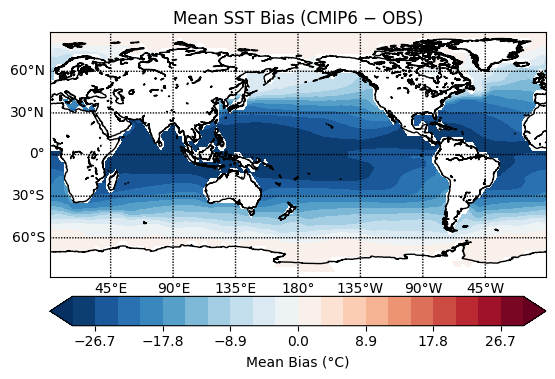

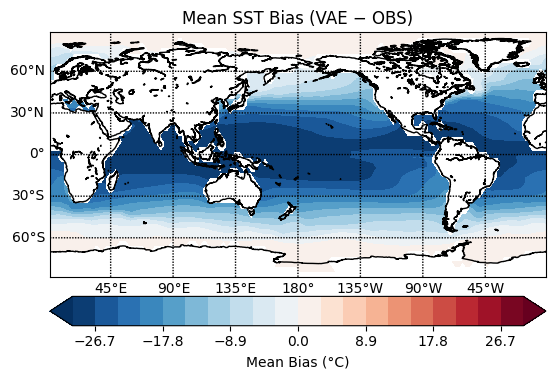

<Figure size 640x480 with 0 Axes>

In [149]:
plot_diverging_map(
    lon_sst, lat_sst,
    mean_bias_cmip_np,
    mean_bias_abs,
    title="Mean SST Bias (CMIP6 − OBS)",
    file_name="/content/drive/MyDrive/VAE_Output/Mean_Bias_CMIP6_OBS.png"
)

plot_diverging_map(
    lon_sst, lat_sst,
    mean_bias_vae_np,
    mean_bias_abs,
    title="Mean SST Bias (VAE − OBS)",
    file_name="/content/drive/MyDrive/VAE_Output/Mean_Bias_VAE_OBS.png"
)

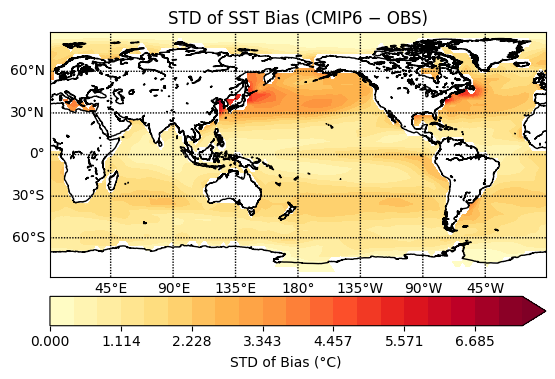

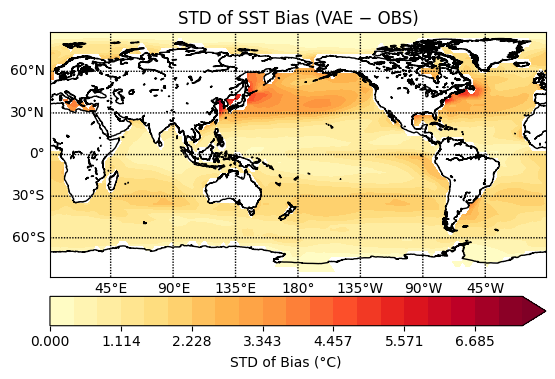

<Figure size 640x480 with 0 Axes>

In [150]:
plot_sequential_map(
    lon_sst, lat_sst,
    std_bias_cmip_np,
    std_bias_max,
    title="STD of SST Bias (CMIP6 − OBS)",
    file_name="/content/drive/MyDrive/VAE_Output/STD_Bias_CMIP6_OBS.png"
)

plot_sequential_map(
    lon_sst, lat_sst,
    std_bias_vae_np,
    std_bias_max,
    title="STD of SST Bias (VAE − OBS)",
    file_name="/content/drive/MyDrive/VAE_Output/STD_Bias_VAE_OBS.png"
)

In [151]:
print(lon_sst.min(), lon_sst.max())

1.25 358.75


In [152]:
import xarray as xr
import numpy as np
import pandas as pd

obs_anom_ds = xr.open_dataset(
    "/content/drive/MyDrive/SST_Data/COBE_SST_resize.nc",
    decode_times=True
)

obs_sst = obs_anom_ds["sst"]

In [153]:
test_time = pd.date_range(
    start="1990-01-01",
    periods=199,
    freq="MS"
)

In [154]:
vae_anom_ds = vae_anom_ds.assign_coords(time=test_time)
ori_anom_ds = ori_anom_ds.assign_coords(time=test_time)

In [155]:
obs_test = obs_sst.sel(
    time=slice(test_time[0], test_time[-1])
)

In [156]:
assert np.all(vae_anom_ds.time.values == obs_test.time.values)
assert np.all(ori_anom_ds.time.values == obs_test.time.values)

In [157]:
obs_clim = obs_test.groupby("time.month").mean("time")

In [158]:
obs_anom = obs_test.groupby("time.month") - obs_clim

In [159]:
vae_sst  = vae_anom_ds["sst"]
cmip_sst = ori_anom_ds["sst"]

In [160]:
vae  = vae_sst.rolling(time=3, center=True).mean().isel(time=slice(1, -1))
cmip = cmip_sst.rolling(time=3, center=True).mean().isel(time=slice(1, -1))
obs  = obs_anom.rolling(time=3, center=True).mean().isel(time=slice(1, -1))

In [161]:
print("VAE shape:", vae.shape)
print("CMIP6 shape:", cmip.shape)
print("OBS shape:", obs.shape)

VAE shape: (10, 197, 48, 144)
CMIP6 shape: (10, 197, 48, 144)
OBS shape: (197, 48, 144)


In [162]:
vae, cmip, obs = xr.align(vae, cmip, obs, join="inner")

In [163]:
bias_cmip_obs = cmip - obs
bias_vae_obs  = vae  - obs

In [164]:
mean_bias_cmip = bias_cmip_obs.mean(dim=("ensemble","time"))
mean_bias_vae  = bias_vae_obs.mean(dim=("ensemble","time"))

In [165]:
std_bias_cmip = bias_cmip_obs.std(dim=("ensemble","time"))
std_bias_vae  = bias_vae_obs.std(dim=("ensemble","time"))

/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [166]:
mean_bias_cmip_np = mean_bias_cmip.values
mean_bias_vae_np  = mean_bias_vae.values

In [167]:
std_bias_cmip_np  = std_bias_cmip.values
std_bias_vae_np   = std_bias_vae.values

In [168]:
print("CMIP6–OBS |Mean Bias|:",
      float(np.nanmean(np.abs(mean_bias_cmip_np))))

print("VAE–OBS |Mean Bias|:",
      float(np.nanmean(np.abs(mean_bias_vae_np))))

print("CMIP6–OBS Bias STD:",
      float(np.nanmean(std_bias_cmip_np)))

print("VAE–OBS Bias STD:",
      float(np.nanmean(std_bias_vae_np)))

CMIP6–OBS |Mean Bias|: 0.08470100874673145
VAE–OBS |Mean Bias|: 0.014458068646490574
CMIP6–OBS Bias STD: 0.5684893281368265
VAE–OBS Bias STD: 0.3882514238357544


In [169]:
mask = np.isnan(obs.mean(dim="time").values)

mean_bias_cmip_np = np.where(mask, np.nan, mean_bias_cmip_np)
mean_bias_vae_np  = np.where(mask, np.nan, mean_bias_vae_np)

In [170]:
mean_bias_abs = np.nanmax(
    np.abs(
        np.stack([mean_bias_cmip_np, mean_bias_vae_np])
    )
)

In [171]:
mean_bias_abs = min(mean_bias_abs, 2.0)  # typical SST bias range

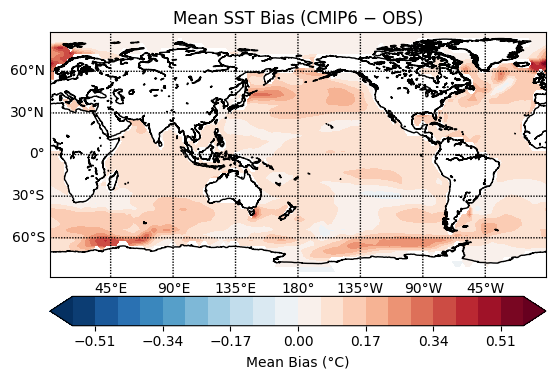

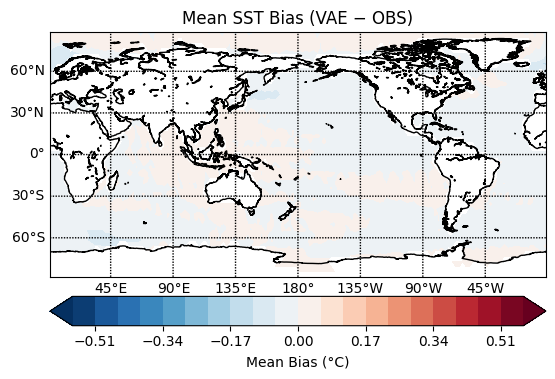

<Figure size 640x480 with 0 Axes>

In [172]:
plot_diverging_map(
    lon_sst,
    lat_sst,
    mean_bias_cmip_np,
    mean_bias_abs,
    title="Mean SST Bias (CMIP6 − OBS)",
    file_name="/content/drive/MyDrive/VAE_Output/Mean_Bias_CMIP6_OBS.png"
)

plot_diverging_map(
    lon_sst,
    lat_sst,
    mean_bias_vae_np,
    mean_bias_abs,
    title="Mean SST Bias (VAE − OBS)",
    file_name="/content/drive/MyDrive/VAE_Output/Mean_Bias_VAE_OBS.png"
)

In [173]:
mean_bias_cmip_abs = np.abs(mean_bias_cmip_np)
mean_bias_vae_abs  = np.abs(mean_bias_vae_np)
mean_bias_cmip_abs = np.where(mask, np.nan, mean_bias_cmip_abs)
mean_bias_vae_abs  = np.where(mask, np.nan, mean_bias_vae_abs)
mean_bias_abs = np.nanmax([
    mean_bias_cmip_abs,
    mean_bias_vae_abs
])

mean_bias_abs = min(mean_bias_abs, 2.0)



In [174]:
def plot_sequential_map(lon, lat, data, vmax, title, file_name):

    fig, ax = plt.subplots(figsize=(10,5))

    m = Basemap(
        projection='cyl',
        llcrnrlat=lat.min(),
        urcrnrlat=lat.max(),
        llcrnrlon=lon.min(),
        urcrnrlon=lon.max(),
        resolution='l',
        ax=ax
    )

    x, y = m(*np.meshgrid(lon, lat))

    cs = m.contourf(
        x, y, data,
        levels=np.linspace(0, vmax, 21),
        cmap="viridis",
        extend="max"
    )

    m.drawcoastlines()

    cbar = plt.colorbar(cs, orientation="horizontal", pad=0.05)
    cbar.set_label("Absolute SST Bias (°C)")

    plt.title(title)

    plt.savefig(file_name, dpi=300, bbox_inches="tight")
    plt.show()

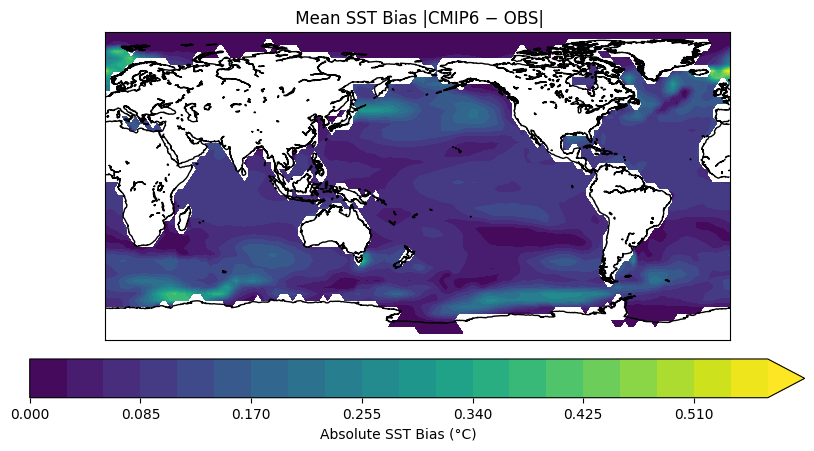

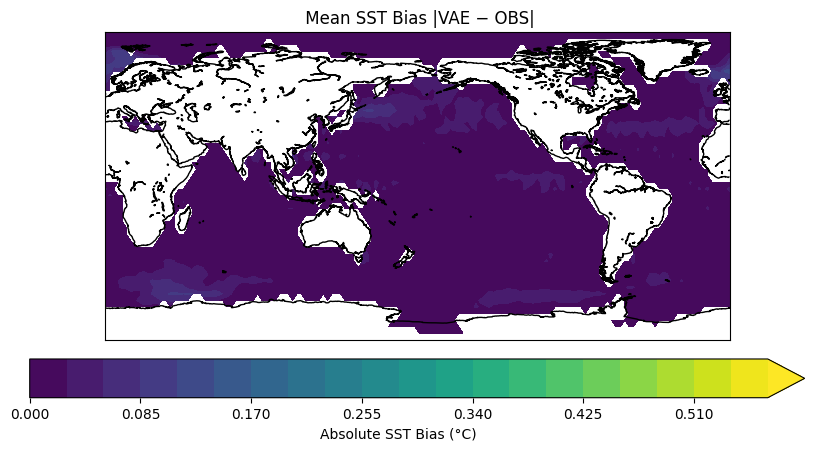

In [175]:
plot_sequential_map(
    lon_sst,
    lat_sst,
    mean_bias_cmip_abs,
    mean_bias_abs,
    title=" Mean SST Bias |CMIP6 − OBS|",
    file_name="/content/drive/MyDrive/VAE_Output/Abs_Mean_Bias_CMIP6_OBS.png"
)

plot_sequential_map(
    lon_sst,
    lat_sst,
    mean_bias_vae_abs,
    mean_bias_abs,
    title=" Mean SST Bias |VAE − OBS|",
    file_name="/content/drive/MyDrive/VAE_Output/Abs_Mean_Bias_VAE_OBS.png"
)

In [176]:
mask = np.isnan(obs.mean(dim="time").values)

std_bias_cmip_np = np.where(mask, np.nan, std_bias_cmip_np)
std_bias_vae_np  = np.where(mask, np.nan, std_bias_vae_np)
std_bias_max = np.nanmax(
    np.stack([std_bias_cmip_np, std_bias_vae_np])
)
std_bias_max = min(std_bias_max, 3)   # typical SST variability range

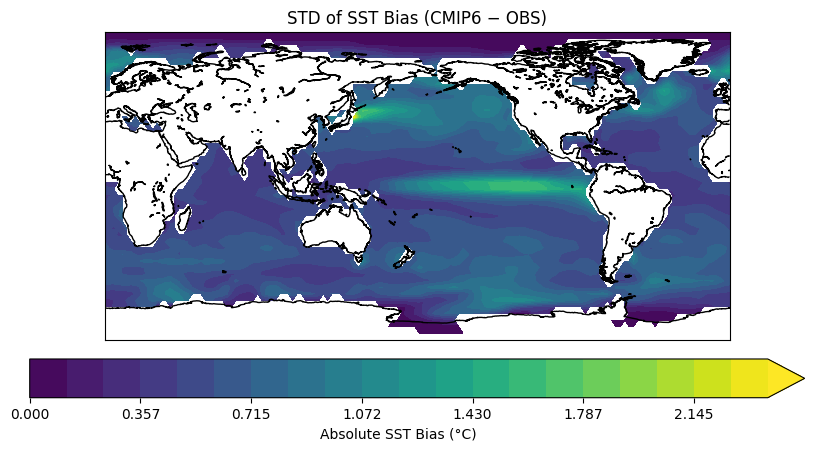

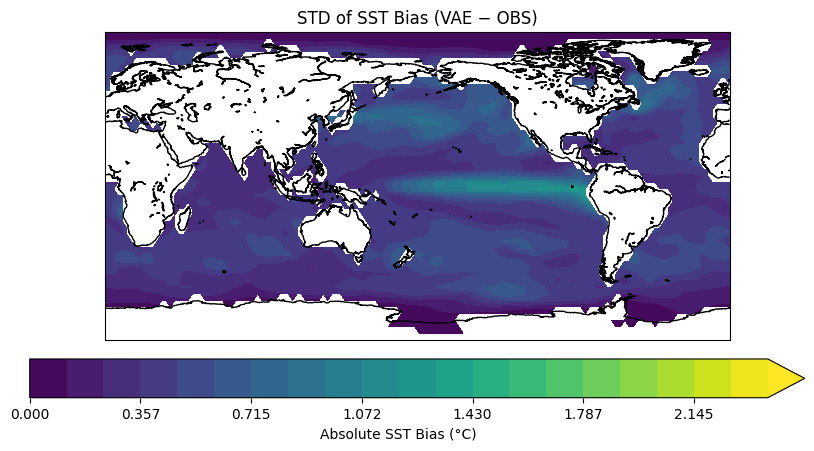

In [177]:
plot_sequential_map(
    lon_sst,
    lat_sst,
    std_bias_cmip_np,
    std_bias_max,
    title="STD of SST Bias (CMIP6 − OBS)",
    file_name="/content/drive/MyDrive/VAE_Output/STD_Bias_CMIP6_OBS.png"
)

plot_sequential_map(
    lon_sst,
    lat_sst,
    std_bias_vae_np,
    std_bias_max,
    title="STD of SST Bias (VAE − OBS)",
    file_name="/content/drive/MyDrive/VAE_Output/STD_Bias_VAE_OBS.png"
)

In [178]:
print("CMIP STD range:",
      np.nanmin(std_bias_cmip_np),
      np.nanmax(std_bias_cmip_np))

print("VAE STD range:",
      np.nanmin(std_bias_vae_np),
      np.nanmax(std_bias_vae_np))

CMIP STD range: 0.0 2.3830004613388702
VAE STD range: 0.004117527 1.3385761
